<a href="https://www.kaggle.com/code/sarraverse/train-b?scriptVersionId=309240222" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Cellule 1 — Installer les dépendances

In [1]:
# ── GPU Compatibility Check ──────────────────────────────────────────
# Python 3.12 + PyTorch 2.2+ requires sm_70+ (Volta or newer).
# The Tesla P100 (sm_60, Pascal) is NOT compatible with Python 3.12 PyTorch builds.
# There is no installable wheel that supports both Python 3.12 and sm_60.
#
# ✅ SOLUTION — Change your Kaggle GPU before running:
#    Notebook Settings → Accelerator → select "GPU T4 x2" (sm_75, fully compatible)
#    If T4 is unavailable, any option other than P100 will work (A100, T4, etc.)
#
# This cell will:
#  - Print your current GPU and confirm compatibility
#  - Raise a clear error early if you have a P100, so you don't waste session time

import torch

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    cap  = torch.cuda.get_device_capability(0)
    print(f"GPU      : {name}")
    print(f"Compute  : sm_{cap[0]}{cap[1]}")

    if cap[0] < 7:
        raise EnvironmentError(
            f"\n\n❌ INCOMPATIBLE GPU DETECTED: {name} (sm_{cap[0]}{cap[1]})\n"
            f"   Python 3.12 + PyTorch 2.x requires sm_70 or higher.\n"
            f"   No compatible wheel exists for Python 3.12 + sm_60.\n\n"
            f"   ✅ FIX: Go to Notebook Settings → Accelerator\n"
            f"          Change from P100 to 'GPU T4 x2' (sm_75) and restart.\n"
        )
    else:
        print(f"\n✅ GPU compatible with current PyTorch — ready to train.")
else:
    print("⚠️  No GPU detected — running on CPU (training will be very slow).")


GPU      : Tesla T4
Compute  : sm_75

✅ GPU compatible with current PyTorch — ready to train.


In [2]:
!pip install transformers sentencepiece -q

# Cellule 2 — Setup et clone du repo

In [3]:
import os, sys

if not os.path.exists('/kaggle/working/sign-language-production'):
    os.system('git clone https://github.com/sarrazer24/sign-language-production.git /kaggle/working/sign-language-production')

data_path = '/kaggle/working/sign-language-production/phase1_text_to_pose/data'
print("Fichiers disponibles :", os.listdir(data_path))


Cloning into '/kaggle/working/sign-language-production'...


Fichiers disponibles : ['normalize.py', 'dataset.py', 'collate.py', 'stats.pt']


In [4]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from transformers import T5EncoderModel, T5Tokenizer
import csv, json, os
from tqdm import tqdm

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
N_KP     = 151
POSE_DIM = N_KP * 3   # 453
BASE     = "/kaggle/input/datasets/sarraverse/how2signdataset"

# CHANGE 5 — reduce diffusion steps 200 → 100
T_DIFF   = 100

# CHANGE 4 — root joint index for root-centred normalisation (MidHip)
ROOT_IDX = 8

print(f"Device : {DEVICE}  |  T_DIFF : {T_DIFF}")


Device : cuda  |  T_DIFF : 100


# Cellule 4 — Dataset et DataLoader

> **CHANGE 4**: Root-centred normalisation — joint 8 (MidHip) subtracted before z-score.

In [5]:
from transformers import T5Tokenizer

TOKENIZER_PATH = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_tokenizer'

class How2SignDataset(Dataset):
    def __init__(self, split='train', stats=None, max_frames=500):
        assert split in ['train', 'dev', 'test']
        self.max_frames  = max_frames
        self.n_keypoints = N_KP

        with open(f"{BASE}/{split}.skels", 'r') as f:
            self.skels_lines = f.readlines()
        with open(f"{BASE}/{split}.text", 'r', encoding='utf-8') as f:
            self.text_lines = f.readlines()
        with open(f"{BASE}/{split}.files", 'r') as f:
            self.files_lines = f.readlines()

        if os.path.exists(TOKENIZER_PATH):
            self.tokenizer = T5Tokenizer.from_pretrained(TOKENIZER_PATH)
            print("✅ Tokenizer chargé depuis le cache local")
        else:
            print("⬇️  Téléchargement tokenizer T5...")
            self.tokenizer = T5Tokenizer.from_pretrained('t5-small')
            self.tokenizer.save_pretrained(TOKENIZER_PATH)
            print(f"✅ Tokenizer sauvegardé dans {TOKENIZER_PATH}")

        self.stats = stats

    def __len__(self):
        return len(self.skels_lines)

    def __getitem__(self, idx):
        vals     = np.array(self.skels_lines[idx].strip().split(), dtype=np.float32)
        n_frames = len(vals) // (self.n_keypoints * 3)
        poses    = vals[:n_frames * self.n_keypoints * 3].reshape(n_frames, self.n_keypoints, 3)

        if n_frames > self.max_frames:
            poses    = poses[:self.max_frames]
            n_frames = self.max_frames

        # CHANGE 4 — subtract root joint to centre the skeleton
        root  = poses[:, ROOT_IDX:ROOT_IDX+1, :]  # (T, 1, 3) broadcast
        poses = poses - root

        if self.stats is not None:
            mean = self.stats['mean'].numpy()
            std  = self.stats['std'].numpy()
            std  = np.where(std < 1e-6, 1.0, std)
            poses = (poses - mean) / std
            poses = np.clip(poses, -3.0, 3.0)

        poses = torch.FloatTensor(poses)
        text  = self.text_lines[idx].strip()
        enc   = self.tokenizer(
            text, return_tensors='pt',
            padding=False, truncation=True, max_length=200
        )
        return {
            'poses'         : poses,
            'pose_length'   : n_frames,
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'text'          : text,
            'file_ref'      : self.files_lines[idx].strip()
        }


def collate_fn(batch):
    batch        = sorted(batch, key=lambda x: x['pose_length'], reverse=True)
    pose_lengths = torch.LongTensor([item['pose_length'] for item in batch])
    T_max        = pose_lengths[0].item()
    B            = len(batch)
    K            = batch[0]['poses'].shape[1]

    poses_padded = torch.zeros(B, T_max, K, 3)
    pose_mask    = torch.zeros(B, T_max, dtype=torch.bool)
    for i, item in enumerate(batch):
        T = item['pose_length']
        poses_padded[i, :T] = item['poses']
        pose_mask[i, :T]    = True

    input_ids = torch.nn.utils.rnn.pad_sequence(
        [item['input_ids'] for item in batch],
        batch_first=True, padding_value=0
    )
    attention_mask = torch.nn.utils.rnn.pad_sequence(
        [item['attention_mask'] for item in batch],
        batch_first=True, padding_value=0
    )
    return {
        'poses'         : poses_padded,
        'pose_mask'     : pose_mask,
        'pose_lengths'  : pose_lengths,
        'input_ids'     : input_ids,
        'attention_mask': attention_mask,
        'texts'         : [item['text'] for item in batch]
    }


# Cellule 5 — Charger stats.pt et créer les DataLoaders

> **CHANGE 4**: Stats recomputed on root-centred poses → saved as `stats_rooted.pt`.
> **CHANGE 5**: batch_size réduit 16→8 pour stabilité avec cross-attention.

In [6]:
# CHANGE 4 — stats must be computed on root-centred poses
stats_path = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/stats_rooted.pt'

if os.path.exists(stats_path):
    stats = torch.load(stats_path)
    print("✅ stats_rooted.pt chargé")
else:
    print("⚠️ Recalcul stats root-centred...")
    all_poses = []
    with open(f"{BASE}/train.skels", 'r') as f:
        for i, line in enumerate(f):
            if i >= 5000: break
            vals     = np.array(line.strip().split(), dtype=np.float32)
            n_frames = len(vals) // (N_KP * 3)
            if n_frames == 0: continue
            poses = vals[:n_frames * N_KP * 3].reshape(n_frames, N_KP, 3)
            # CHANGE 4 — centre before computing stats
            root  = poses[:, ROOT_IDX:ROOT_IDX+1, :]
            poses = poses - root
            all_poses.append(poses[:100])
    all_poses = np.concatenate(all_poses, axis=0)
    stats = {
        'mean': torch.FloatTensor(all_poses.mean(axis=0)),
        'std' : torch.FloatTensor(all_poses.std(axis=0))
    }
    torch.save(stats, stats_path)
    print("✅ stats_rooted.pt sauvegardé")

# CHANGE 5 — batch_size 16 → 8 for stability
train_ds = How2SignDataset('train', stats=stats, max_frames=500)
dev_ds   = How2SignDataset('dev',   stats=stats, max_frames=500)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)
dev_loader   = DataLoader(dev_ds,   batch_size=8, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

print(f"Train : {len(train_ds)} samples — {len(train_loader)} batches")
print(f"Dev   : {len(dev_ds)}   samples — {len(dev_loader)} batches")

batch = next(iter(train_loader))
print(f"Batch poses shape : {batch['poses'].shape}")
print(f"Batch texte[0]    : {batch['texts'][0][:60]}")


⚠️ Recalcul stats root-centred...
✅ stats_rooted.pt sauvegardé


⬇️  Téléchargement tokenizer T5...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer sauvegardé dans /kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_tokenizer
✅ Tokenizer chargé depuis le cache local
Train : 31046 samples — 3881 batches
Dev   : 1739   samples — 218 batches
Batch poses shape : torch.Size([8, 114, 151, 3])
Batch texte[0]    : "Alright, we're going to give this a stir to let the butter 


# Cellule 6 — Bloc 1 : TextEncoder

> **CHANGE 1**: Returns full token embeddings `(B, N, 512)` instead of mean-pooled `(B, 512)`.
> A `.pool()` helper is kept for STC / ablation branch.

In [7]:
T5_MODEL_PATH = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_model'

class TextEncoder(nn.Module):
    """
    CHANGE 1 — forward() returns full token sequence (B, N, 512).
    pool() returns mean-pooled (B, 512) for FiLM/STC conditioning.
    """
    def __init__(self, model_name='t5-small', output_dim=512):
        super().__init__()
        if os.path.exists(T5_MODEL_PATH):
            self.encoder = T5EncoderModel.from_pretrained(T5_MODEL_PATH)
            print("✅ T5EncoderModel chargé depuis le cache local")
        else:
            print("⬇️  Téléchargement T5EncoderModel...")
            self.encoder = T5EncoderModel.from_pretrained(model_name)
            self.encoder.save_pretrained(T5_MODEL_PATH)
            print(f"✅ T5EncoderModel sauvegardé dans {T5_MODEL_PATH}")

        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.encoder.encoder.block[-2:].parameters():
            param.requires_grad = True

        hidden_size = self.encoder.config.d_model
        self.proj   = nn.Linear(hidden_size, output_dim) \
                      if hidden_size != output_dim else nn.Identity()

    def forward(self, input_ids, attention_mask):
        """Returns (B, N, 512) — full token sequence."""
        outputs       = self.encoder(input_ids=input_ids,
                                     attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state   # (B, N, hidden)
        return self.proj(hidden_states)             # (B, N, 512)

    def pool(self, input_ids, attention_mask):
        """Returns (B, 512) mean-pooled summary for FiLM/STC."""
        tokens = self.forward(input_ids, attention_mask)
        mask   = attention_mask.unsqueeze(-1).float()
        return (tokens * mask).sum(1) / mask.sum(1).clamp(1e-9)


# Cellule 7 — Bloc 2 : TimestepEmbedding

> Inchangé.

In [8]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def sinusoidal_embedding(self, timesteps):
        device = timesteps.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -math.log(10000) *
            torch.arange(half, device=device) / (half - 1)
        )
        args = timesteps[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    def forward(self, timesteps):
        return self.mlp(self.sinusoidal_embedding(timesteps))  # (B, 512)


# Cellule 8 — Bloc 3 : SemanticTimestepConditioning

> **CHANGE 6**: STC now operates on mean-pooled text (single token). Full-sequence
> attention is delegated to the U-Net bottleneck cross-attention (CHANGE 2).

In [9]:
class SemanticTimestepConditioning(nn.Module):
    """
    CHANGE 6 — Accepts pooled text vector (B, 512) rather than full tokens.
    Cross-attention: Q=timestep, K=V=pooled_c (single token).
    Full-sequence attention is in the U-Net bottleneck (CHANGE 2).
    """
    def __init__(self, dim=512, num_heads=8):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, batch_first=True
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def forward(self, t_embd, c_pooled):
        # t_embd   : (B, 512)
        # c_pooled : (B, 512)
        t           = t_embd.unsqueeze(1)    # (B, 1, 512)
        c           = c_pooled.unsqueeze(1)  # (B, 1, 512)
        attn_out, _ = self.cross_attn(query=t, key=c, value=c)
        t           = self.norm1(t + attn_out)
        t           = self.norm2(t + self.ffn(t))
        return t.squeeze(1)                  # (B, 512)


# Cellule 9 — Bloc 4 : UNet1D

> **CHANGE 2**: `BottleneckCrossAttention` added after bottleneck ResBlock.
> Q = pose features, K/V = full token sequence.
> **CHANGE 3**: FiLM amplification `1.5×` for stronger conditioning.

In [10]:
# CHANGE 2 — Bottleneck cross-attention: pose features attend to text tokens
class BottleneckCrossAttention(nn.Module):
    """
    Q = bottleneck feature map  (B, T_feat, C)
    K = V = text token sequence (B, N, 512)  projected to C if needed
    """
    def __init__(self, feat_dim, text_dim=512, num_heads=8):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, feat_dim) \
                         if text_dim != feat_dim else nn.Identity()
        self.attn      = nn.MultiheadAttention(
            embed_dim=feat_dim, num_heads=num_heads,
            batch_first=True, dropout=0.0
        )
        self.norm      = nn.LayerNorm(feat_dim)

    def forward(self, x, c_tokens):
        """
        x        : (B, C, T_feat)
        c_tokens : (B, N, 512)
        returns  : (B, C, T_feat)
        """
        q           = x.permute(0, 2, 1)          # (B, T_feat, C)
        kv          = self.text_proj(c_tokens)     # (B, N, C)
        attn_out, _ = self.attn(q, kv, kv)        # (B, T_feat, C)
        out         = self.norm(q + attn_out)
        return out.permute(0, 2, 1)                # (B, C, T_feat)


class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim=512):
        super().__init__()
        self.conv1     = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.conv2     = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.cond_proj = nn.Linear(cond_dim, out_ch * 2)
        self.norm1     = nn.GroupNorm(8, out_ch)
        self.norm2     = nn.GroupNorm(8, out_ch)
        self.act       = nn.SiLU()
        self.res_proj  = nn.Conv1d(in_ch, out_ch, 1) \
                         if in_ch != out_ch else nn.Identity()

    def forward(self, x, z_c):
        h            = self.act(self.norm1(self.conv1(x)))
        scale, shift = self.cond_proj(z_c).chunk(2, dim=-1)
        # CHANGE 3 — stronger FiLM: 1.5× amplification
        h = h * (1 + 1.5 * scale.unsqueeze(-1)) + 1.5 * shift.unsqueeze(-1)
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.res_proj(x)


class UNet1D(nn.Module):
    """
    CHANGE 2 — bottleneck includes BottleneckCrossAttention over text tokens.
    """
    def __init__(self, pose_dim=453, cond_dim=512, base_ch=128, text_dim=512):
        super().__init__()
        C = base_ch
        self.input_proj    = nn.Conv1d(pose_dim, C, 1)
        self.enc1          = ResBlock1D(C,     C,     cond_dim)
        self.enc2          = ResBlock1D(C,     C * 2, cond_dim)
        self.enc3          = ResBlock1D(C * 2, C * 4, cond_dim)
        self.down1         = nn.Conv1d(C,     C,     3, stride=2, padding=1)
        self.down2         = nn.Conv1d(C * 2, C * 2, 3, stride=2, padding=1)
        self.down3         = nn.Conv1d(C * 4, C * 4, 3, stride=2, padding=1)
        self.bottleneck    = ResBlock1D(C * 4, C * 4, cond_dim)
        # CHANGE 2 — cross-attention after bottleneck
        self.bottleneck_ca = BottleneckCrossAttention(
            feat_dim=C * 4, text_dim=text_dim, num_heads=8
        )
        self.dec3          = ResBlock1D(C * 8, C * 4, cond_dim)
        self.dec2          = ResBlock1D(C * 6, C * 2, cond_dim)
        self.dec1          = ResBlock1D(C * 3, C,     cond_dim)
        self.up3           = nn.ConvTranspose1d(C * 4, C * 4, 4, stride=2, padding=1)
        self.up2           = nn.ConvTranspose1d(C * 4, C * 4, 4, stride=2, padding=1)
        self.up1           = nn.ConvTranspose1d(C * 2, C * 2, 4, stride=2, padding=1)
        self.output_proj   = nn.Conv1d(C, pose_dim, 1)

    def _match_size(self, x, target):
        if x.shape[2] != target.shape[2]:
            x = x[:, :, :target.shape[2]]
        return x

    def forward(self, x, z_c, c_tokens):
        """
        x        : (B, T, pose_dim)
        z_c      : (B, 512)        — FiLM condition
        c_tokens : (B, N, 512)     — full token sequence for bottleneck CA
        """
        x  = self.input_proj(x.transpose(1, 2))    # (B, C, T)
        s1 = self.enc1(x,  z_c);  x = self.down1(s1)
        s2 = self.enc2(x,  z_c);  x = self.down2(s2)
        s3 = self.enc3(x,  z_c);  x = self.down3(s3)
        x  = self.bottleneck(x, z_c)
        x  = self.bottleneck_ca(x, c_tokens)        # CHANGE 2
        x  = self.dec3(torch.cat([self._match_size(self.up3(x), s3), s3], dim=1), z_c)
        x  = self.dec2(torch.cat([self._match_size(self.up2(x), s2), s2], dim=1), z_c)
        x  = self.dec1(torch.cat([self._match_size(self.up1(x), s1), s1], dim=1), z_c)
        return self.output_proj(x).transpose(1, 2)  # (B, T, pose_dim)


# Cellule 10 — Bloc 5 : GaussianDiffusion

> **CHANGE 5**: `T=100` (was 200). Cosine schedule auto-adjusts.
> `compute_loss` and `sample` now accept `c_tokens` for the U-Net.

In [11]:
BONE_PAIRS = [
    (0,1),(1,2),(2,3),(3,4),
    (1,5),(5,6),(6,7),
    (1,8),(8,9),(9,10),(10,11),
    (8,12),(12,13),(13,14)
]

def bone_length_loss(x_pred, x_gt, mask):
    B, T, D = x_pred.shape
    kp_pred = x_pred.view(B, T, -1, 3)
    kp_gt   = x_gt.view(B, T, -1, 3)
    loss = 0.0
    for i, j in BONE_PAIRS:
        pred_len = torch.norm(kp_pred[:, :, i] - kp_pred[:, :, j], dim=-1)
        gt_len   = torch.norm(kp_gt[:, :, i]   - kp_gt[:, :, j],   dim=-1)
        loss += ((pred_len - gt_len) ** 2 * mask).sum() / (mask.sum() + 1e-8)
    return loss / len(BONE_PAIRS)


class GaussianDiffusion(nn.Module):
    # CHANGE 5 — T=100
    def __init__(self, model, T=100):
        super().__init__()
        self.model = model
        self.T     = T

        betas          = self._cosine_schedule(T)
        alphas         = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer('betas',          betas)
        self.register_buffer('alphas',         alphas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('sqrt_acp',       torch.sqrt(alphas_cumprod))
        self.register_buffer('sqrt_one_minus', torch.sqrt(1 - alphas_cumprod))

    def _cosine_schedule(self, T, s=0.008):
        steps = torch.arange(T + 1, dtype=torch.float32)
        f     = torch.cos((steps / T + s) / (1 + s) * math.pi / 2) ** 2
        betas = 1 - f[1:] / f[:-1]
        return torch.clamp(betas, 0.0001, 0.9999)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        s  = self.sqrt_acp[t][:, None, None]
        sm = self.sqrt_one_minus[t][:, None, None]
        return s * x0 + sm * noise, noise

    def compute_loss(self, x0, z_c, c_tokens, pose_mask):
        """CHANGE 1/2 — receives c_tokens and passes them to U-Net."""
        B = x0.shape[0]
        t = torch.randint(0, self.T, (B,), device=x0.device)

        x_t, noise = self.q_sample(x0, t)
        mask    = pose_mask.unsqueeze(-1).float()
        mask_2d = pose_mask.float()

        x0_pred = self.model(x_t, z_c, c_tokens)
        x0_pred = torch.clamp(x0_pred, -3.0, 3.0)

        sqrt_acp = self.sqrt_acp[t][:, None, None]
        sqrt_om  = self.sqrt_one_minus[t][:, None, None]
        noise_recon = (x_t - sqrt_acp * x0_pred) / (sqrt_om + 1e-8)

        loss_x0    = ((x0_pred - x0) ** 2 * mask).sum() / (mask.sum() + 1e-8)
        loss_noise = ((noise_recon - noise) ** 2 * mask).sum() / (mask.sum() + 1e-8)
        loss_bone  = bone_length_loss(x0_pred, x0, mask_2d)

        return loss_x0 + 0.5 * loss_noise + 0.1 * loss_bone

    @torch.no_grad()
    def p_sample(self, x_t, t_val, z_c, c_tokens):
        B  = x_t.shape[0]
        t  = torch.full((B,), t_val, device=x_t.device, dtype=torch.long)

        beta     = self.betas[t][:, None, None]
        alpha    = self.alphas[t][:, None, None]
        alpha_cp = self.alphas_cumprod[t][:, None, None]

        x0_pred = self.model(x_t, z_c, c_tokens)
        x0_pred = torch.clamp(x0_pred, -3.0, 3.0)

        coef1 = torch.sqrt(alpha_cp)
        coef2 = torch.sqrt(1 - alpha_cp)
        eps   = (x_t - coef1 * x0_pred) / (coef2 + 1e-8)

        mean  = (1 / torch.sqrt(alpha)) * (x_t - beta / coef2 * eps)
        mean  = torch.clamp(mean, -3.0, 3.0)

        if t_val > 0:
            noise = torch.randn_like(x_t)
            mean  = mean + 0.5 * torch.sqrt(beta) * noise

        return mean

    @torch.no_grad()
    def sample(self, z_c_fn, c_tokens, n_frames, batch_size, device, pose_dim):
        """CHANGE 1/2 — c_tokens passed through entire reverse loop."""
        x = torch.randn(batch_size, n_frames, pose_dim, device=device) * 0.9

        for t_val in reversed(range(self.T)):
            t_tensor = torch.full((batch_size,), t_val, device=device, dtype=torch.long)
            z_c      = z_c_fn(t_tensor)
            x        = self.p_sample(x, t_val, z_c, c_tokens)

        return x


# Cellule 11 — Modèle complet ApproachB

> All changes wired together.

In [12]:
class ApproachB(nn.Module):
    # CHANGE 5 — default T = T_DIFF = 100
    def __init__(self, T=T_DIFF, use_contribution=True):
        super().__init__()
        self.use_contribution = use_contribution
        self.text_encoder  = TextEncoder()
        self.timestep_emb  = TimestepEmbedding(dim=512)
        self.semantic_cond = SemanticTimestepConditioning(dim=512)
        # CHANGE 1/2 — UNet accepts text_dim for cross-attention
        self.unet          = UNet1D(pose_dim=POSE_DIM, base_ch=128, text_dim=512)
        self.diffusion     = GaussianDiffusion(self.unet, T=T)
        # CHANGE 6 — simple projection for ablation baseline
        self.naive_proj    = nn.Linear(512, 512)

    def get_condition(self, t_embd, c_pooled):
        """CHANGE 6 — both branches use pooled text; tokens handled by U-Net CA."""
        if self.use_contribution:
            return self.semantic_cond(t_embd, c_pooled)
        else:
            return self.naive_proj(t_embd + c_pooled)

    def forward(self, batch):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        poses          = batch['poses'].to(DEVICE)
        pose_mask      = batch['pose_mask'].to(DEVICE)

        B, T, K, _ = poses.shape
        x0         = poses.reshape(B, T, K * 3)

        # CHANGE 1 — get both full tokens and pooled summary
        c_tokens = self.text_encoder(input_ids, attention_mask)       # (B, N, 512)
        c_pooled = self.text_encoder.pool(input_ids, attention_mask)  # (B, 512)

        t      = torch.randint(0, self.diffusion.T, (B,), device=DEVICE)
        t_embd = self.timestep_emb(t)
        z_c    = self.get_condition(t_embd, c_pooled)

        # CHANGE 1/2 — pass c_tokens to diffusion loss
        return self.diffusion.compute_loss(x0, z_c, c_tokens, pose_mask)

    @torch.no_grad()
    def generate(self, input_ids, attention_mask, n_frames=55):
        self.eval()
        B        = input_ids.shape[0]
        c_tokens = self.text_encoder(input_ids, attention_mask)       # (B, N, 512)
        c_pooled = self.text_encoder.pool(input_ids, attention_mask)  # (B, 512)

        def z_c_fn(t_tensor):
            t_embd = self.timestep_emb(t_tensor)
            return self.get_condition(t_embd, c_pooled)

        # CHANGE 1/2 — pass c_tokens to sample
        poses = self.diffusion.sample(
            z_c_fn, c_tokens, n_frames,
            batch_size=B, device=DEVICE, pose_dim=POSE_DIM
        )

        # Mild variance guard (only intervene for explosions > 2.0 std)
        current_std = poses.std()
        if current_std > 2.0:
            poses = poses * (0.9 / current_std)
        poses = torch.clamp(poses, -3.0, 3.0)

        return poses.reshape(B, n_frames, N_KP, 3)


# ── Smoke test ────────────────────────────────────────────────────
model_test = ApproachB(T=T_DIFF, use_contribution=True).to(DEVICE)
batch_test = next(iter(train_loader))
loss_test  = model_test(batch_test)
print(f"✅ Forward pass OK — Loss : {loss_test.item():.4f}")
total = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {total:,}")
del model_test


⬇️  Téléchargement T5EncoderModel...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ T5EncoderModel sauvegardé dans /kaggle/working/sign-language-production/phase1_text_to_pose/data/t5_model
✅ Forward pass OK — Loss : 1036.4293
Paramètres entraînables : 24,072,261


# Cellule 12 — Fonctions d'entraînement et d'évaluation

In [13]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Train", leave=False):
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss = model(batch)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    for batch in tqdm(loader, desc="Eval", leave=False):
        with torch.cuda.amp.autocast():
            loss = model(batch)
        total_loss += loss.item()
    return total_loss / len(loader)


# Chargement des modèles entraînés

> Ce notebook **ne réentraîne pas** les modèles.
> Il charge les checkpoints produits par **train-b8-WITH.ipynb** et **train-b8-WITHOUT.ipynb**.

> **Prérequis :** avoir exécuté les deux notebooks et récupéré leurs outputs dans
> `/kaggle/working/outputs_approach_b/` (via *Output* → *Add as dataset* ou un dataset Kaggle partagé).

> Fichiers attendus :
> - `model_with_contribution.pt`
> - `model_without_contribution.pt`
> - `history_with.json`
> - `history_without.json`

In [14]:
# ── Chargement des checkpoints et historiques ───────────────────────
# Paths produits par train-b8-WITH.ipynb et train-b8-WITHOUT.ipynb
# Adaptez si vous avez changé output_dir dans ces notebooks.

OUTPUT_DIR  = '/kaggle/input/datasets/sarraverse/outputs-approach-b'

CKPT_WITH    = f'{OUTPUT_DIR}/model_with_contribution.pt'
CKPT_WITHOUT = f'{OUTPUT_DIR}/model_without_contribution.pt'
HIST_WITH    = f'{OUTPUT_DIR}/history_with.json'
HIST_WITHOUT = f'{OUTPUT_DIR}/history_without.json'

import os, json as _json

# ── Charger model WITH ───────────────────────────────────────────────
assert os.path.exists(CKPT_WITH),    f"❌ Fichier introuvable : {CKPT_WITH}"
assert os.path.exists(HIST_WITH),    f"❌ Fichier introuvable : {HIST_WITH}"

model_with = ApproachB(T=T_DIFF, use_contribution=True).to(DEVICE)
model_with.load_state_dict(torch.load(CKPT_WITH, map_location=DEVICE))
model_with.eval()
print(f"✅ model_with chargé depuis {CKPT_WITH}")

with open(HIST_WITH) as f:
    history_with = _json.load(f)
print(f"   Epochs enregistrées : {len(history_with['train'])}  |  Best dev : {min(history_with['dev']):.4f}")

# ── Charger model WITHOUT ────────────────────────────────────────────
assert os.path.exists(CKPT_WITHOUT), f"❌ Fichier introuvable : {CKPT_WITHOUT}"
assert os.path.exists(HIST_WITHOUT), f"❌ Fichier introuvable : {HIST_WITHOUT}"

model_without = ApproachB(T=T_DIFF, use_contribution=False).to(DEVICE)
model_without.load_state_dict(torch.load(CKPT_WITHOUT, map_location=DEVICE))
model_without.eval()
print(f"✅ model_without chargé depuis {CKPT_WITHOUT}")

with open(HIST_WITHOUT) as f:
    history_without = _json.load(f)
print(f"   Epochs enregistrées : {len(history_without['train'])}  |  Best dev : {min(history_without['dev']):.4f}")

print("\n✅ Les deux modèles sont prêts pour l'évaluation et la visualisation.")


Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

✅ T5EncoderModel chargé depuis le cache local
✅ model_with chargé depuis /kaggle/input/datasets/sarraverse/outputs-approach-b/model_with_contribution.pt
   Epochs enregistrées : 120  |  Best dev : 82.1558


Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

✅ T5EncoderModel chargé depuis le cache local
✅ model_without chargé depuis /kaggle/input/datasets/sarraverse/outputs-approach-b/model_without_contribution.pt
   Epochs enregistrées : 120  |  Best dev : 83.3425

✅ Les deux modèles sont prêts pour l'évaluation et la visualisation.


# Courbes de convergence comparatives

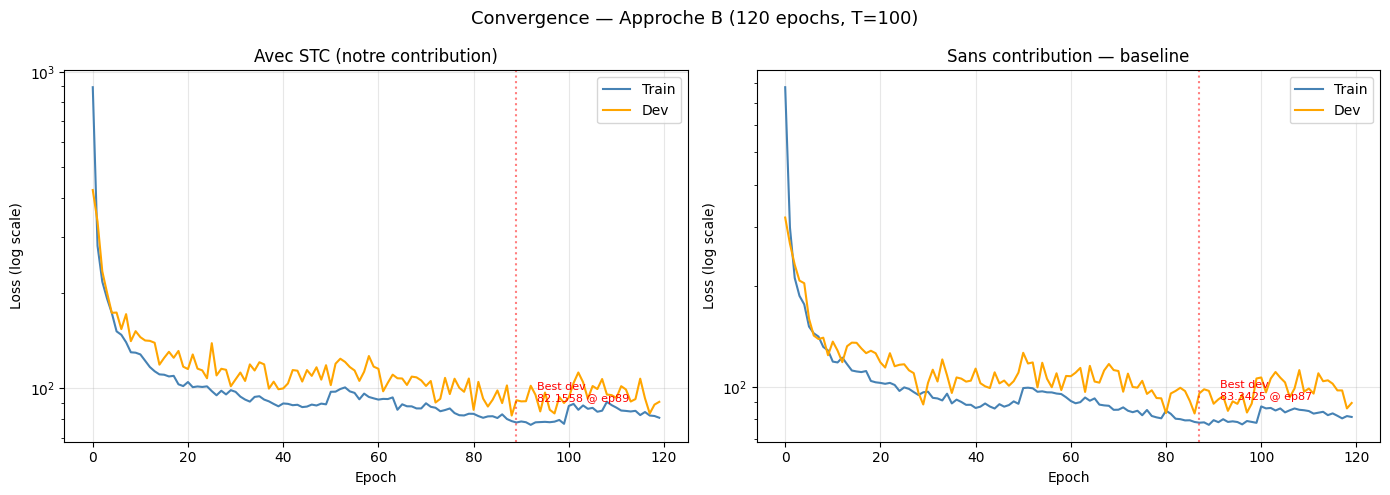

Meilleure dev loss AVEC : 82.1558  @ epoch 89
Meilleure dev loss SANS : 83.3425  @ epoch 87


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, title in [
    (axes[0], history_with,    'Avec STC (notre contribution)'),
    (axes[1], history_without, 'Sans contribution — baseline')
]:
    ax.plot(hist['train'], label='Train', color='steelblue', linewidth=1.5)
    ax.plot(hist['dev'],   label='Dev',   color='orange',    linewidth=1.5)
    ax.set_yscale('log')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (log scale)')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    best_ep = int(np.argmin(hist['dev'])) + 1
    best_v  = min(hist['dev'])
    ax.axvline(best_ep, color='red', linestyle=':', alpha=0.5)
    ax.annotate(f"Best dev\n{best_v:.4f} @ ep{best_ep}",
                xy=(best_ep, best_v), xytext=(15, 10),
                textcoords='offset points', fontsize=8, color='red')

plt.suptitle(f'Convergence — Approche B (120 epochs, T={T_DIFF})', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/convergence_approach_b.png', dpi=150)
plt.show()

print(f"Meilleure dev loss AVEC : {min(history_with['dev']):.4f}  "
      f"@ epoch {np.argmin(history_with['dev'])+1}")
print(f"Meilleure dev loss SANS : {min(history_without['dev']):.4f}  "
      f"@ epoch {np.argmin(history_without['dev'])+1}")


# Loss curves — Ablation Study

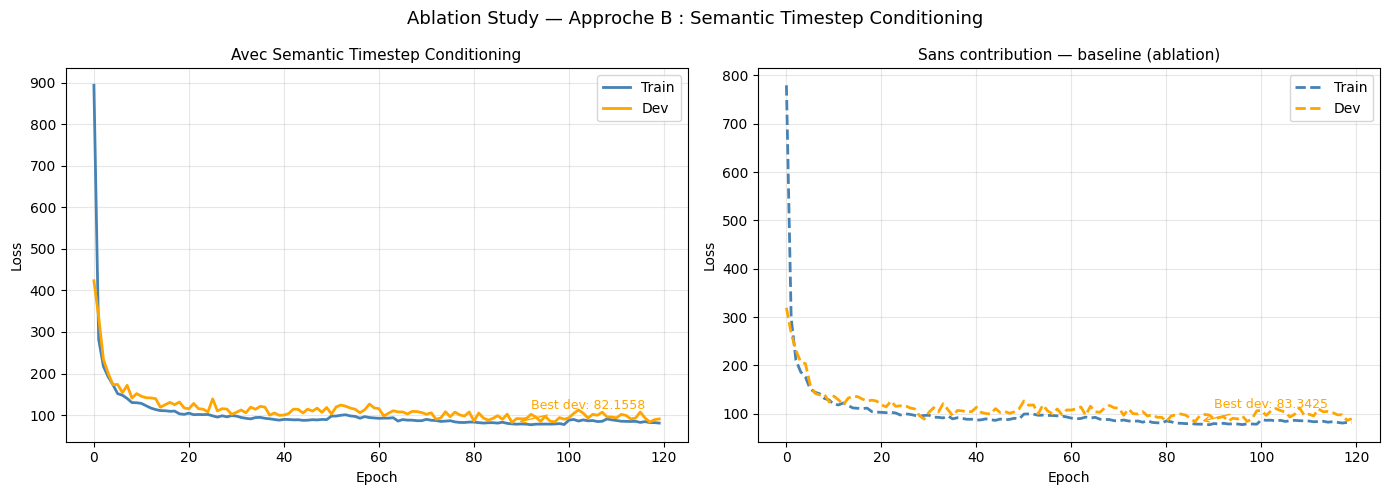

Meilleure dev loss AVEC : 82.1558
Meilleure dev loss SANS : 83.3425
Gain de notre contribution : +1.1867


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_with['train'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(history_with['dev'],   label='Dev',   color='orange',    linewidth=2)
axes[0].set_title('Avec Semantic Timestep Conditioning', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].annotate(f"Best dev: {min(history_with['dev']):.4f}",
                 xy=(np.argmin(history_with['dev'])+1, min(history_with['dev'])),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))

axes[1].plot(history_without['train'], label='Train', color='steelblue',
             linewidth=2, linestyle='--')
axes[1].plot(history_without['dev'],   label='Dev',   color='orange',
             linewidth=2, linestyle='--')
axes[1].set_title('Sans contribution — baseline (ablation)', fontsize=11)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].annotate(f"Best dev: {min(history_without['dev']):.4f}",
                 xy=(np.argmin(history_without['dev'])+1, min(history_without['dev'])),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))

plt.suptitle('Ablation Study — Approche B : Semantic Timestep Conditioning', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curves_approach_b.png', dpi=150)
plt.show()

gain = min(history_without['dev']) - min(history_with['dev'])
print(f"Meilleure dev loss AVEC : {min(history_with['dev']):.4f}")
print(f"Meilleure dev loss SANS : {min(history_without['dev']):.4f}")
print(f"Gain de notre contribution : {gain:+.4f}")


# Vérification plages de valeurs

In [17]:
batch = next(iter(dev_loader))
gt    = batch['poses']

input_ids      = batch['input_ids'].to(DEVICE)
attention_mask = batch['attention_mask'].to(DEVICE)
n_frames       = int(batch['pose_lengths'].float().mean().item())

with torch.no_grad():
    pred = model_with.generate(input_ids, attention_mask, n_frames=n_frames)

print("Espace normalisé :")
print(f"  GT    — min: {gt.min():.4f}, max: {gt.max():.4f}, mean: {gt.mean():.4f}")
print(f"  Pred  — min: {pred.min():.4f}, max: {pred.max():.4f}, mean: {pred.mean():.4f}")

mean_np     = stats['mean'].numpy()
std_np      = stats['std'].numpy()
gt_denorm   = gt.numpy()   * std_np + mean_np
pred_denorm = pred.cpu().numpy() * std_np + mean_np

print("\nEspace original (dénormalisé) :")
print(f"  GT    — min: {gt_denorm.min():.4f}, max: {gt_denorm.max():.4f}")
print(f"  Pred  — min: {pred_denorm.min():.4f}, max: {pred_denorm.max():.4f}")


Espace normalisé :
  GT    — min: -3.0000, max: 3.0000, mean: 0.0724
  Pred  — min: -1.7409, max: 1.7815, mean: -0.0541

Espace original (dénormalisé) :
  GT    — min: -0.4284, max: 1.0861
  Pred  — min: -0.2521, max: 0.9112


# Fonctions d'évaluation — MPJPE + DTW

In [18]:
@torch.no_grad()
def compute_mpjpe(model, loader, stats, n_samples=200):
    """
    MPJPE en espace dénormalisé.
    Génère chaque séquence avec sa vraie longueur individuelle.
    """
    model.eval()
    mean_t = stats['mean'].to(DEVICE)   # (151, 3)
    std_t  = stats['std'].to(DEVICE)    # (151, 3)
    scores = []
    count  = 0

    for batch in tqdm(loader, desc="MPJPE", leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        gt_poses       = batch['poses'].to(DEVICE)
        pose_lengths   = batch['pose_lengths']
        B              = gt_poses.shape[0]

        for i in range(B):
            L           = pose_lengths[i].item()
            pred_i      = model.generate(input_ids[i:i+1],
                                         attention_mask[i:i+1],
                                         n_frames=L)           # (1, L, 151, 3)
            gt_i        = gt_poses[i, :L]
            gt_denorm   = gt_i     * std_t + mean_t
            pred_denorm = pred_i[0] * std_t + mean_t
            dist        = torch.norm(pred_denorm - gt_denorm, dim=-1)  # (L, 151)
            scores.append(dist.mean().item())

        count += B
        if count >= n_samples:
            break

    return float(np.mean(scores))


In [19]:
def dtw_distance(seq1, seq2):
    """
    DTW entre deux séquences de poses.
    seq1 : (T1, 151, 3) — numpy, espace dénormalisé
    seq2 : (T2, 151, 3) — numpy, espace dénormalisé
    Retourne le coût DTW normalisé par (T1 + T2).
    """
    T1, T2 = len(seq1), len(seq2)

    # Aplatir les poses : (T, 151*3)
    s1 = seq1.reshape(T1, -1).astype(np.float32)
    s2 = seq2.reshape(T2, -1).astype(np.float32)

    # Matrice de coût : distance euclidienne entre chaque paire de frames
    # Vectorisé : évite la double boucle Python
    diff = s1[:, None, :] - s2[None, :, :]          # (T1, T2, D)
    cost = np.sqrt((diff ** 2).sum(axis=-1))         # (T1, T2)

    # Programmation dynamique DTW
    dtw = np.full((T1 + 1, T2 + 1), np.inf, dtype=np.float32)
    dtw[0, 0] = 0.0
    for i in range(1, T1 + 1):
        for j in range(1, T2 + 1):
            dtw[i, j] = cost[i-1, j-1] + min(
                dtw[i-1, j],    # insertion
                dtw[i, j-1],    # deletion
                dtw[i-1, j-1]   # match
            )

    # Normaliser par la longueur du chemin optimal
    return float(dtw[T1, T2]) / (T1 + T2)


@torch.no_grad()
def compute_dtw(model, loader, stats, n_samples=100):
    """
    DTW moyen sur n_samples séquences du loader.
    Moins de samples que MPJPE car DTW est O(T1*T2) en temps.
    """
    model.eval()
    mean_np = stats['mean'].numpy()   # (151, 3)
    std_np  = stats['std'].numpy()    # (151, 3)
    mean_t  = stats['mean'].to(DEVICE)
    std_t   = stats['std'].to(DEVICE)

    scores = []
    count  = 0

    for batch in tqdm(loader, desc="DTW", leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        gt_poses       = batch['poses'].to(DEVICE)
        pose_lengths   = batch['pose_lengths']
        B              = gt_poses.shape[0]

        for i in range(B):
            L = pose_lengths[i].item()

            # Générer la séquence prédite
            pred_i = model.generate(input_ids[i:i+1],
                                    attention_mask[i:i+1],
                                    n_frames=L)            # (1, L, 151, 3) normalisé

            # Dénormaliser
            gt_denorm   = (gt_poses[i, :L]  * std_t + mean_t).cpu().numpy()  # (L, 151, 3)
            pred_denorm = (pred_i[0]         * std_t + mean_t).cpu().numpy()  # (L, 151, 3)

            dtw_score = dtw_distance(pred_denorm, gt_denorm)
            scores.append(dtw_score)

        count += B
        if count >= n_samples:
            break

    return float(np.mean(scores))


# BLEU-4 — Semantic Faithfulness

In [20]:
# ════════════════════════════════════════════════════════════
# BLEU-4 — Semantic Faithfulness (quantized pose sequences)
# Method : k-means quantize pose frames → token sequences
#          → BLEU-4 between predicted and GT token sequences
# ════════════════════════════════════════════════════════════

from collections import Counter
import math
from sklearn.cluster import MiniBatchKMeans

def build_pose_vocabulary(loader, stats, n_clusters=256, n_samples=3000):
    """
    Fit a k-means vocabulary on GT pose frames (denormalised).
    Returns a fitted MiniBatchKMeans used to tokenise any pose sequence.
    """
    mean_np = stats['mean'].numpy()
    std_np  = stats['std'].numpy()
    frames  = []
    count   = 0

    for batch in loader:
        gt        = batch['poses']                        # (B, T, 151, 3) normalised
        gt_denorm = gt.numpy() * std_np + mean_np
        B, T, K, D = gt_denorm.shape
        frames.append(gt_denorm.reshape(B * T, K * D))   # (B*T, 453)
        count += B
        if count >= n_samples:
            break

    frames = np.concatenate(frames, axis=0)
    print(f"  Fitting k-means on {len(frames)} frames ({n_clusters} clusters)...")
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42,
                             batch_size=2048, n_init=5)
    kmeans.fit(frames)
    print(f"  ✅ Vocabulary built (inertia={kmeans.inertia_:.1f})")
    return kmeans


def poses_to_tokens(poses_np, kmeans):
    """poses_np : (T, 151, 3) denormalised → list of int cluster ids"""
    return kmeans.predict(poses_np.reshape(len(poses_np), -1)).tolist()


def _bleu_ngram_precision(hyp, ref, n):
    if len(hyp) < n or len(ref) < n:
        return 0.0
    hyp_ng = Counter(tuple(hyp[i:i+n]) for i in range(len(hyp) - n + 1))
    ref_ng = Counter(tuple(ref[i:i+n]) for i in range(len(ref)  - n + 1))
    clipped = sum(min(c, ref_ng[ng]) for ng, c in hyp_ng.items())
    total   = sum(hyp_ng.values())
    return clipped / total if total > 0 else 0.0


def sentence_bleu4(hyp_tokens, ref_tokens):
    """Sentence-level BLEU-4 with brevity penalty."""
    c, r = len(hyp_tokens), len(ref_tokens)
    bp   = 1.0 if c >= r else math.exp(1 - r / c)
    prec = [_bleu_ngram_precision(hyp_tokens, ref_tokens, n) for n in range(1, 5)]
    if any(p == 0 for p in prec):
        return 0.0
    return bp * math.exp(sum(math.log(p) for p in prec) / 4)


@torch.no_grad()
def compute_bleu4(model, loader, stats, kmeans, n_samples=200):
    """Corpus-level mean sentence BLEU-4 (0–1, higher = better)."""
    model.eval()
    mean_t = stats['mean'].to(DEVICE)
    std_t  = stats['std'].to(DEVICE)
    scores = []
    count  = 0

    for batch in tqdm(loader, desc="BLEU-4", leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        gt_poses       = batch['poses'].to(DEVICE)
        pose_lengths   = batch['pose_lengths']
        B              = gt_poses.shape[0]

        for i in range(B):
            L = pose_lengths[i].item()
            pred_i      = model.generate(input_ids[i:i+1],
                                         attention_mask[i:i+1],
                                         n_frames=L)          # (1, L, 151, 3)
            gt_denorm   = (gt_poses[i, :L] * std_t + mean_t).cpu().numpy()
            pred_denorm = (pred_i[0]        * std_t + mean_t).cpu().numpy()
            ref_tokens  = poses_to_tokens(gt_denorm,   kmeans)
            hyp_tokens  = poses_to_tokens(pred_denorm, kmeans)
            scores.append(sentence_bleu4(hyp_tokens, ref_tokens))

        count += B
        if count >= n_samples:
            break

    return float(np.mean(scores))


# Calcul des métriques

In [21]:
print("Calcul MPJPE...")
mpjpe_with    = compute_mpjpe(model_with,    dev_loader, stats, n_samples=200)
mpjpe_without = compute_mpjpe(model_without, dev_loader, stats, n_samples=200)

print("\nCalcul DTW (plus lent — O(T²) par séquence)...")
dtw_with    = compute_dtw(model_with,    dev_loader, stats, n_samples=100)
dtw_without = compute_dtw(model_without, dev_loader, stats, n_samples=100)

print("\nConstruction vocabulaire poses pour BLEU-4...")
pose_kmeans = build_pose_vocabulary(dev_loader, stats, n_clusters=256, n_samples=3000)

print("\nCalcul BLEU-4...")
bleu4_with    = compute_bleu4(model_with,    dev_loader, stats, pose_kmeans, n_samples=200)
bleu4_without = compute_bleu4(model_without, dev_loader, stats, pose_kmeans, n_samples=200)

print(f"\n{'='*55}")
print(f"{'Métrique':<20} {'AVEC STC':>12} {'SANS STC':>12} {'Gain':>10}")
print(f"{'-'*55}")
print(f"{'MPJPE ↓':<20} {mpjpe_with:>12.4f} {mpjpe_without:>12.4f} "
      f"{mpjpe_without - mpjpe_with:>+10.4f}")
print(f"{'DTW ↓':<20} {dtw_with:>12.4f} {dtw_without:>12.4f} "
      f"{dtw_without - dtw_with:>+10.4f}")
print(f"{'BLEU-4 ↑':<20} {bleu4_with:>12.4f} {bleu4_without:>12.4f} "
      f"{bleu4_with - bleu4_without:>+10.4f}")
print(f"{'='*55}")
print("↓ = plus bas est mieux  |  ↑ = plus haut est mieux  |  Gain positif = STC aide")


Calcul MPJPE...



Calcul DTW (plus lent — O(T²) par séquence)...



Construction vocabulaire poses pour BLEU-4...


  Fitting k-means on 192131 frames (256 clusters)...
  ✅ Vocabulary built (inertia=44293.4)

Calcul BLEU-4...



Métrique                 AVEC STC     SANS STC       Gain
-------------------------------------------------------
MPJPE ↓                    0.0957       0.0973    +0.0016
DTW ↓                      0.6396       0.6392    -0.0003
BLEU-4 ↑                   0.0083       0.0046    +0.0037
↓ = plus bas est mieux  |  ↑ = plus haut est mieux  |  Gain positif = STC aide


# Visualisation des métriques

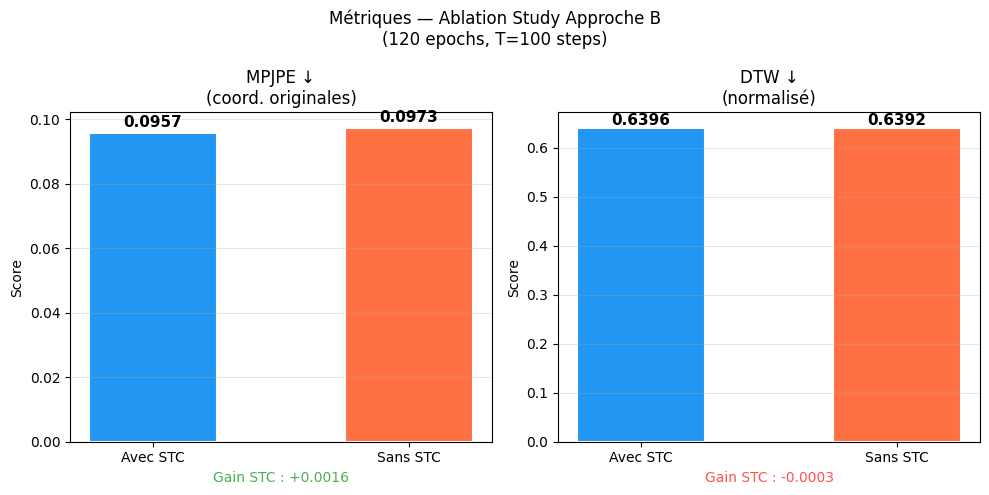

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

metrics = {
    'MPJPE ↓\n(coord. originales)': (mpjpe_with, mpjpe_without),
    'DTW ↓\n(normalisé)':           (dtw_with,   dtw_without),
}

for ax, (metric_name, (val_with, val_without)) in zip(axes, metrics.items()):
    bars = ax.bar(['Avec STC', 'Sans STC'],
                  [val_with, val_without],
                  color=['#2196F3', '#FF7043'],
                  width=0.5, edgecolor='white', linewidth=1.5)
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, [val_with, val_without]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    gain = val_without - val_with
    color = '#4CAF50' if gain > 0 else '#FF5252'
    ax.set_xlabel(f"Gain STC : {gain:+.4f}", color=color, fontsize=10)

plt.suptitle(f'Métriques — Ablation Study Approche B\n(120 epochs, T={T_DIFF} steps)',
             fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/metrics_approach_b.png', dpi=150)
plt.show()


# Visualisation squelettes connectés

In [23]:
# Diagnostic : comparer les distributions GT vs Pred en espace normalisé
batch = next(iter(dev_loader))
gt    = batch['poses']   # (B, T, 151, 3) normalisé

input_ids      = batch['input_ids'].to(DEVICE)
attention_mask = batch['attention_mask'].to(DEVICE)
n_frames       = int(batch['pose_lengths'].float().mean().item())

with torch.no_grad():
    pred = model_with.generate(input_ids, attention_mask, n_frames=n_frames)

print("=== Espace normalisé ===")
print(f"GT   — mean: {gt.mean():.3f}  std: {gt.std():.3f}  min: {gt.min():.3f}  max: {gt.max():.3f}")
print(f"Pred — mean: {pred.mean():.3f}  std: {pred.std():.3f}  min: {pred.min():.3f}  max: {pred.max():.3f}")

# Si Pred std >> GT std → le modèle génère trop de variance → poses explosées
# Si Pred mean ≠ GT mean → le modèle génère dans la mauvaise plage

=== Espace normalisé ===
GT   — mean: 0.072  std: 1.067  min: -3.000  max: 3.000
Pred — mean: -0.053  std: 0.251  min: -1.561  max: 1.714



──────────────────────────────────────────────────
Visualisation sample 0
──────────────────────────────────────────────────


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

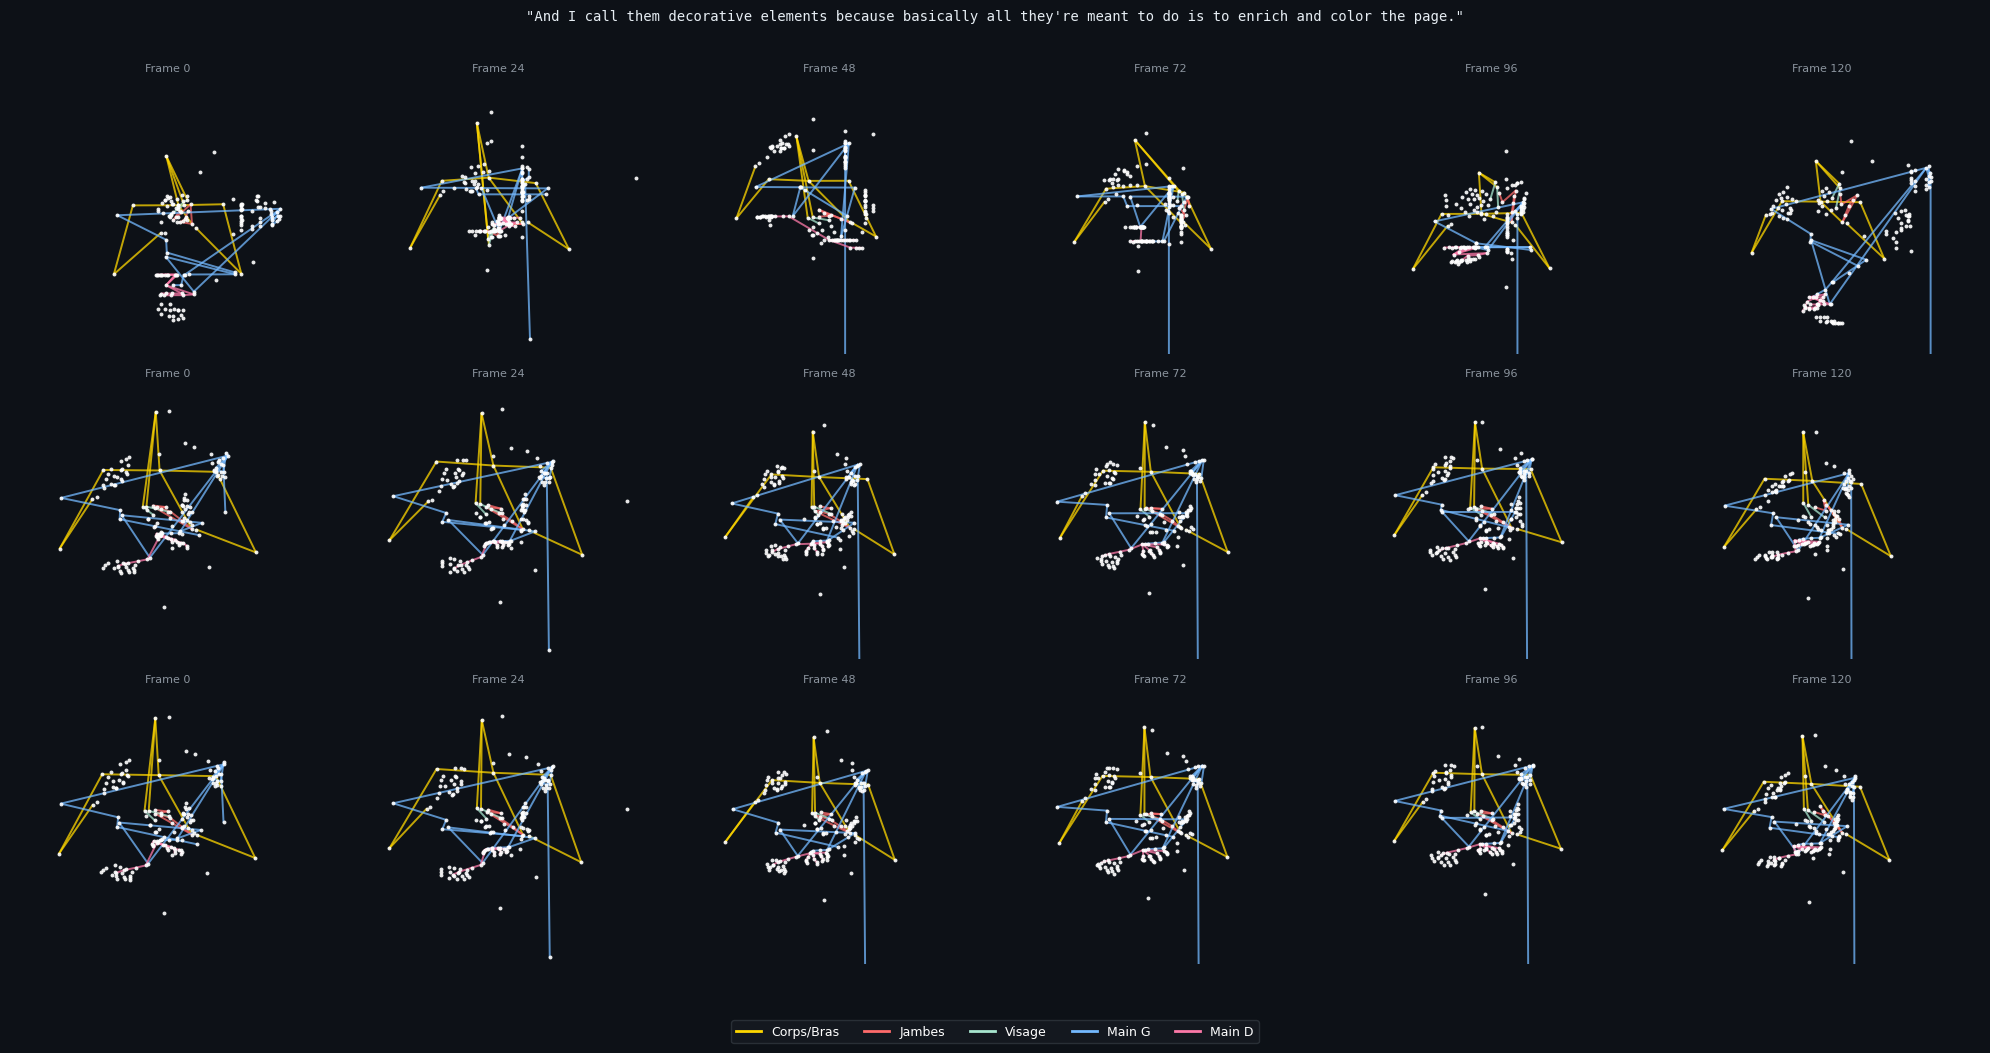

✅ viz_full_0.png sauvegardé


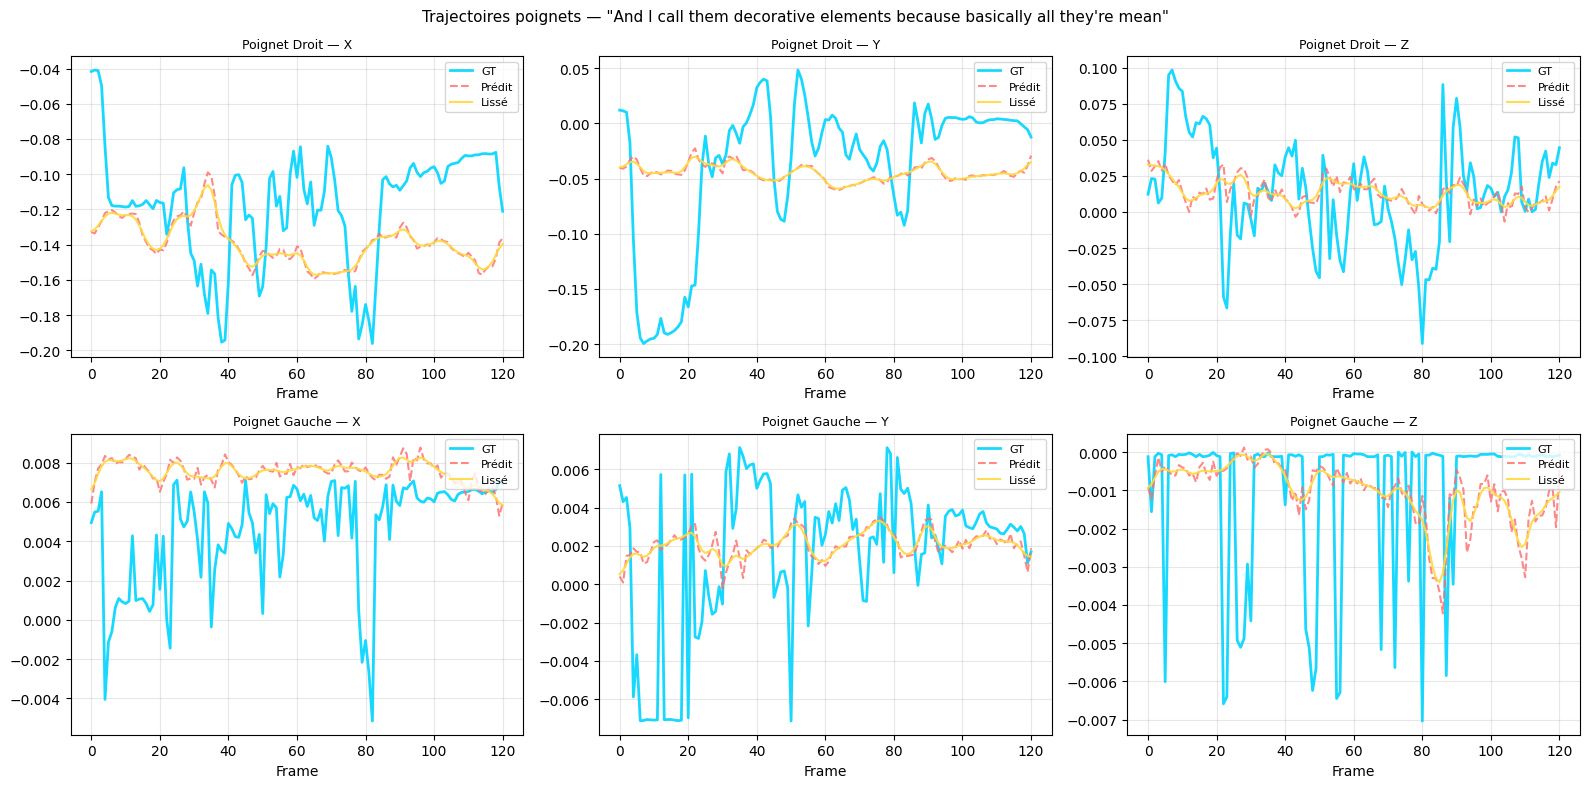

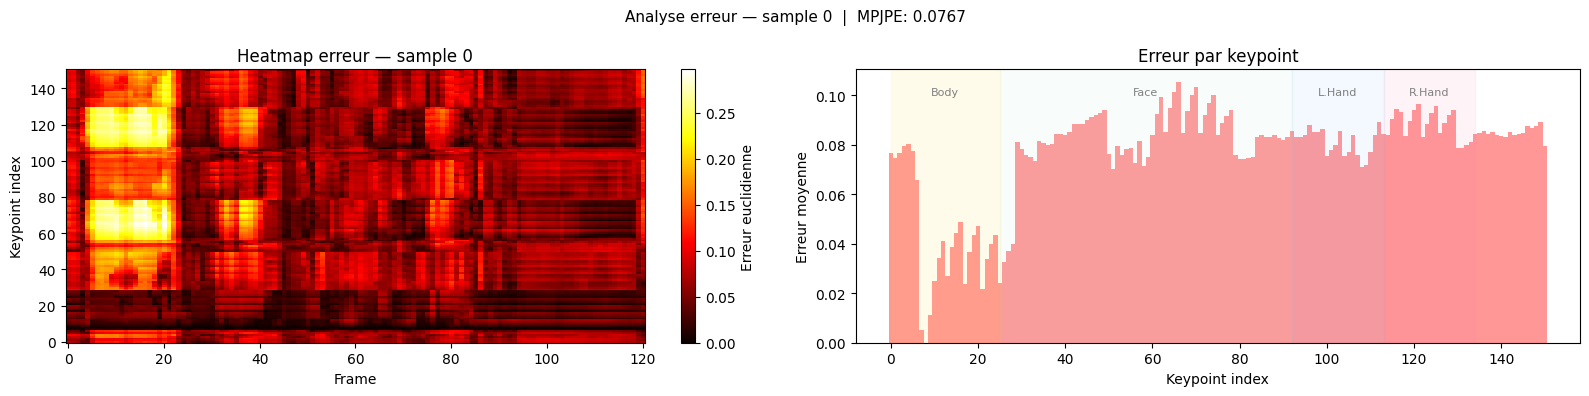

Sample 0 : 121 frames
  MPJPE          : 0.0767
  MPJPE lissé    : 0.0764
  Keypoint pire  : #66 (erreur moy = 0.1053)
  Région pire    : Face

──────────────────────────────────────────────────
Visualisation sample 5
──────────────────────────────────────────────────


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

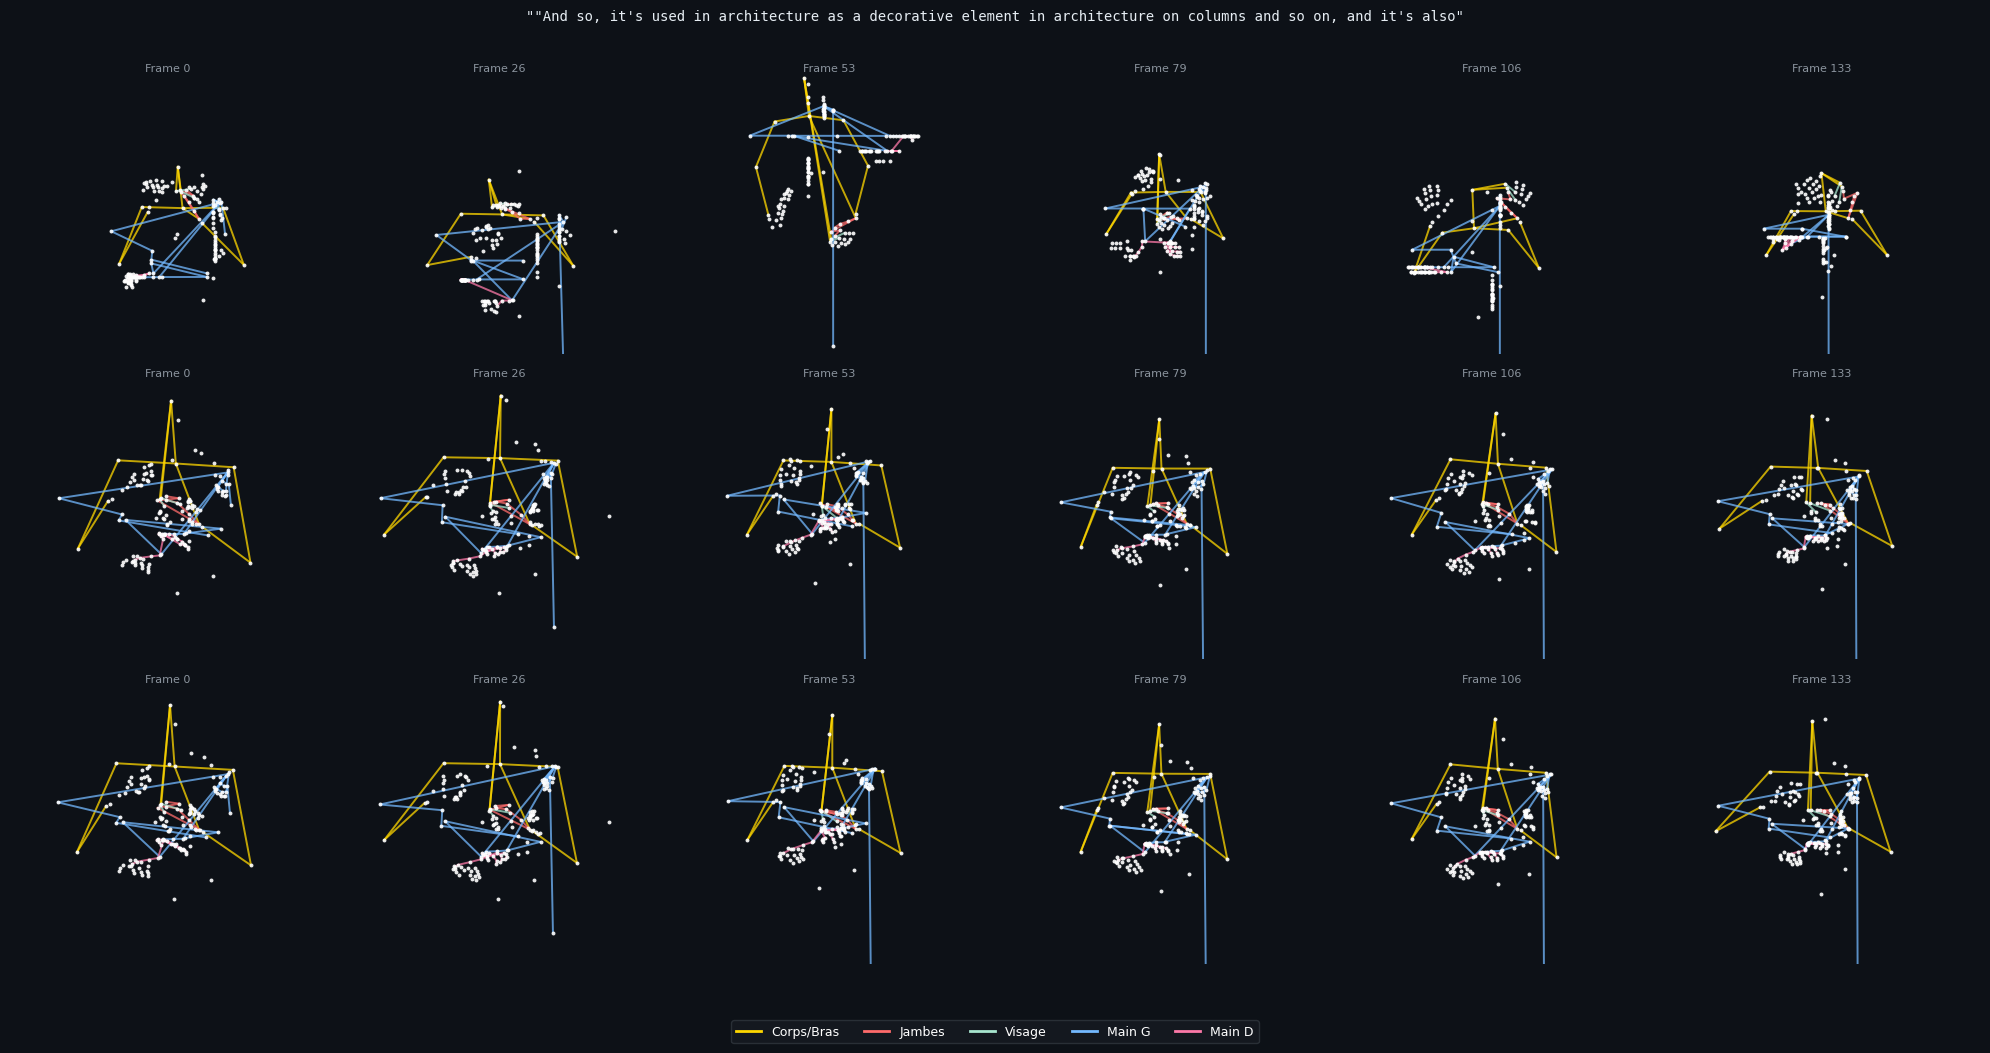

✅ viz_full_5.png sauvegardé


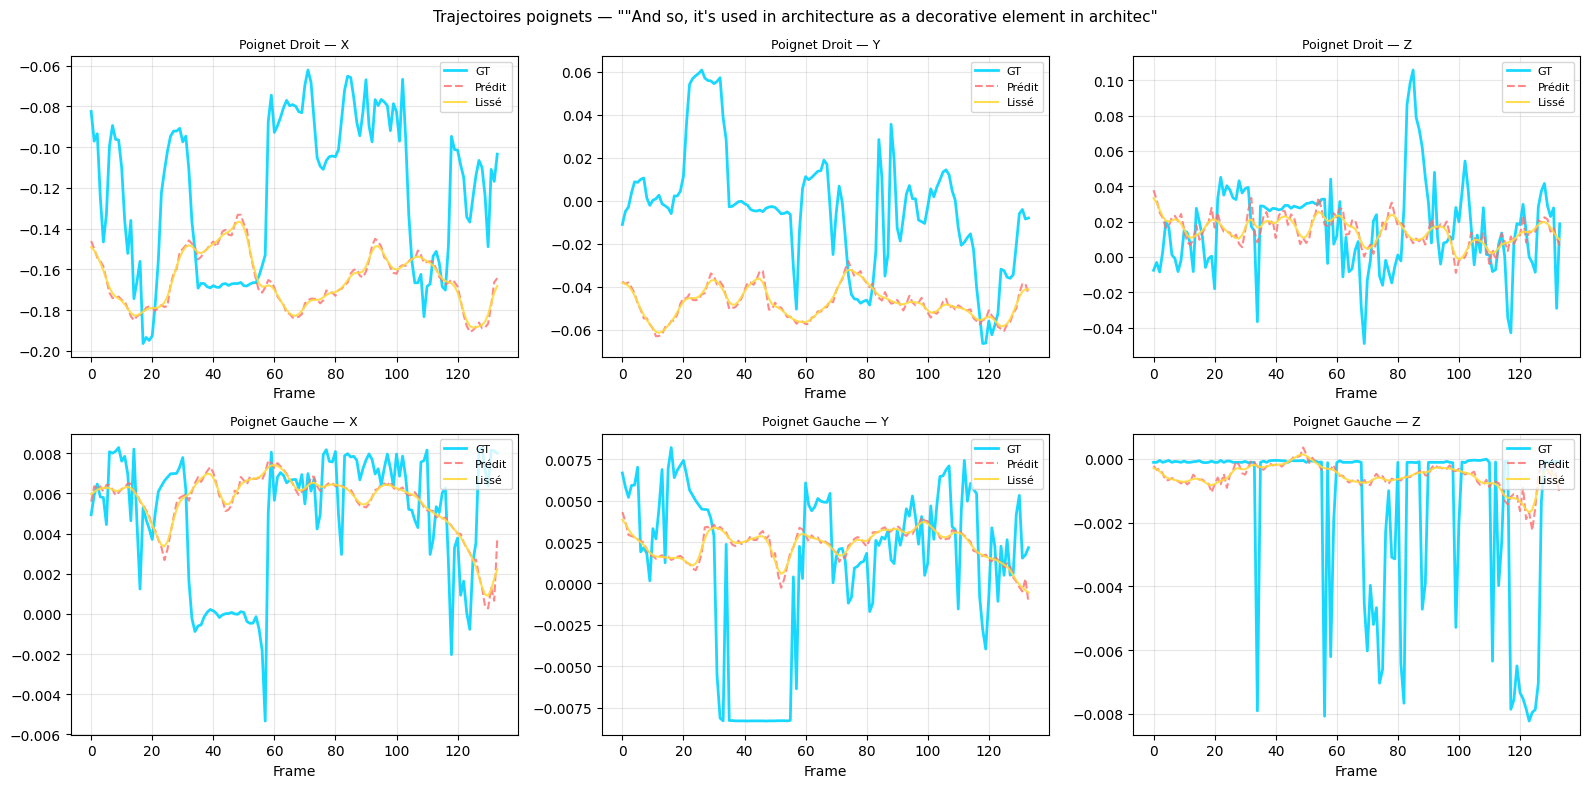

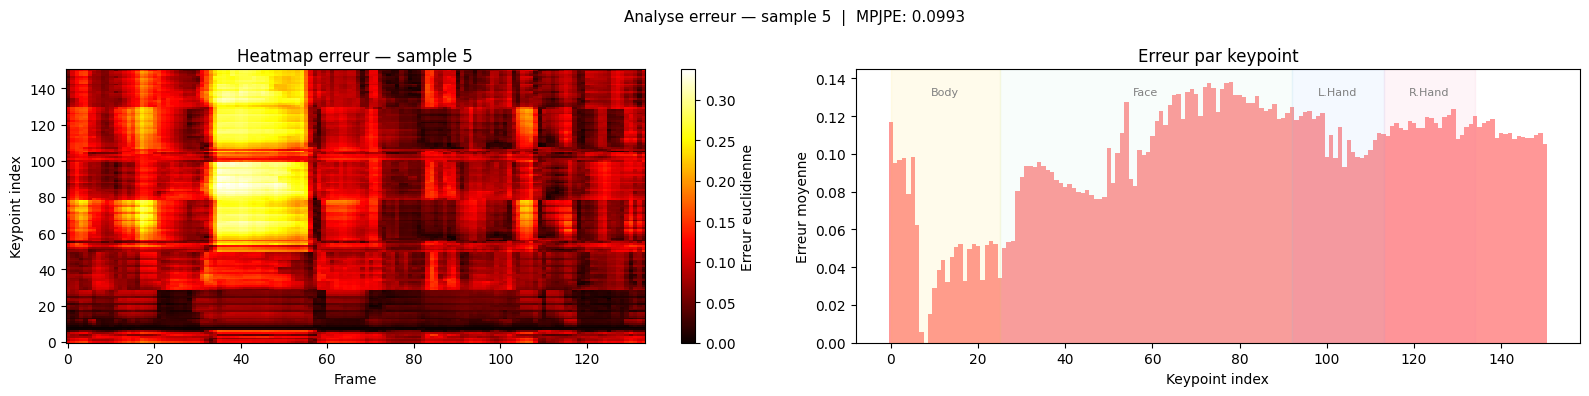

Sample 5 : 134 frames
  MPJPE          : 0.0993
  MPJPE lissé    : 0.0991
  Keypoint pire  : #78 (erreur moy = 0.1379)
  Région pire    : Face

──────────────────────────────────────────────────
Visualisation sample 10
──────────────────────────────────────────────────


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

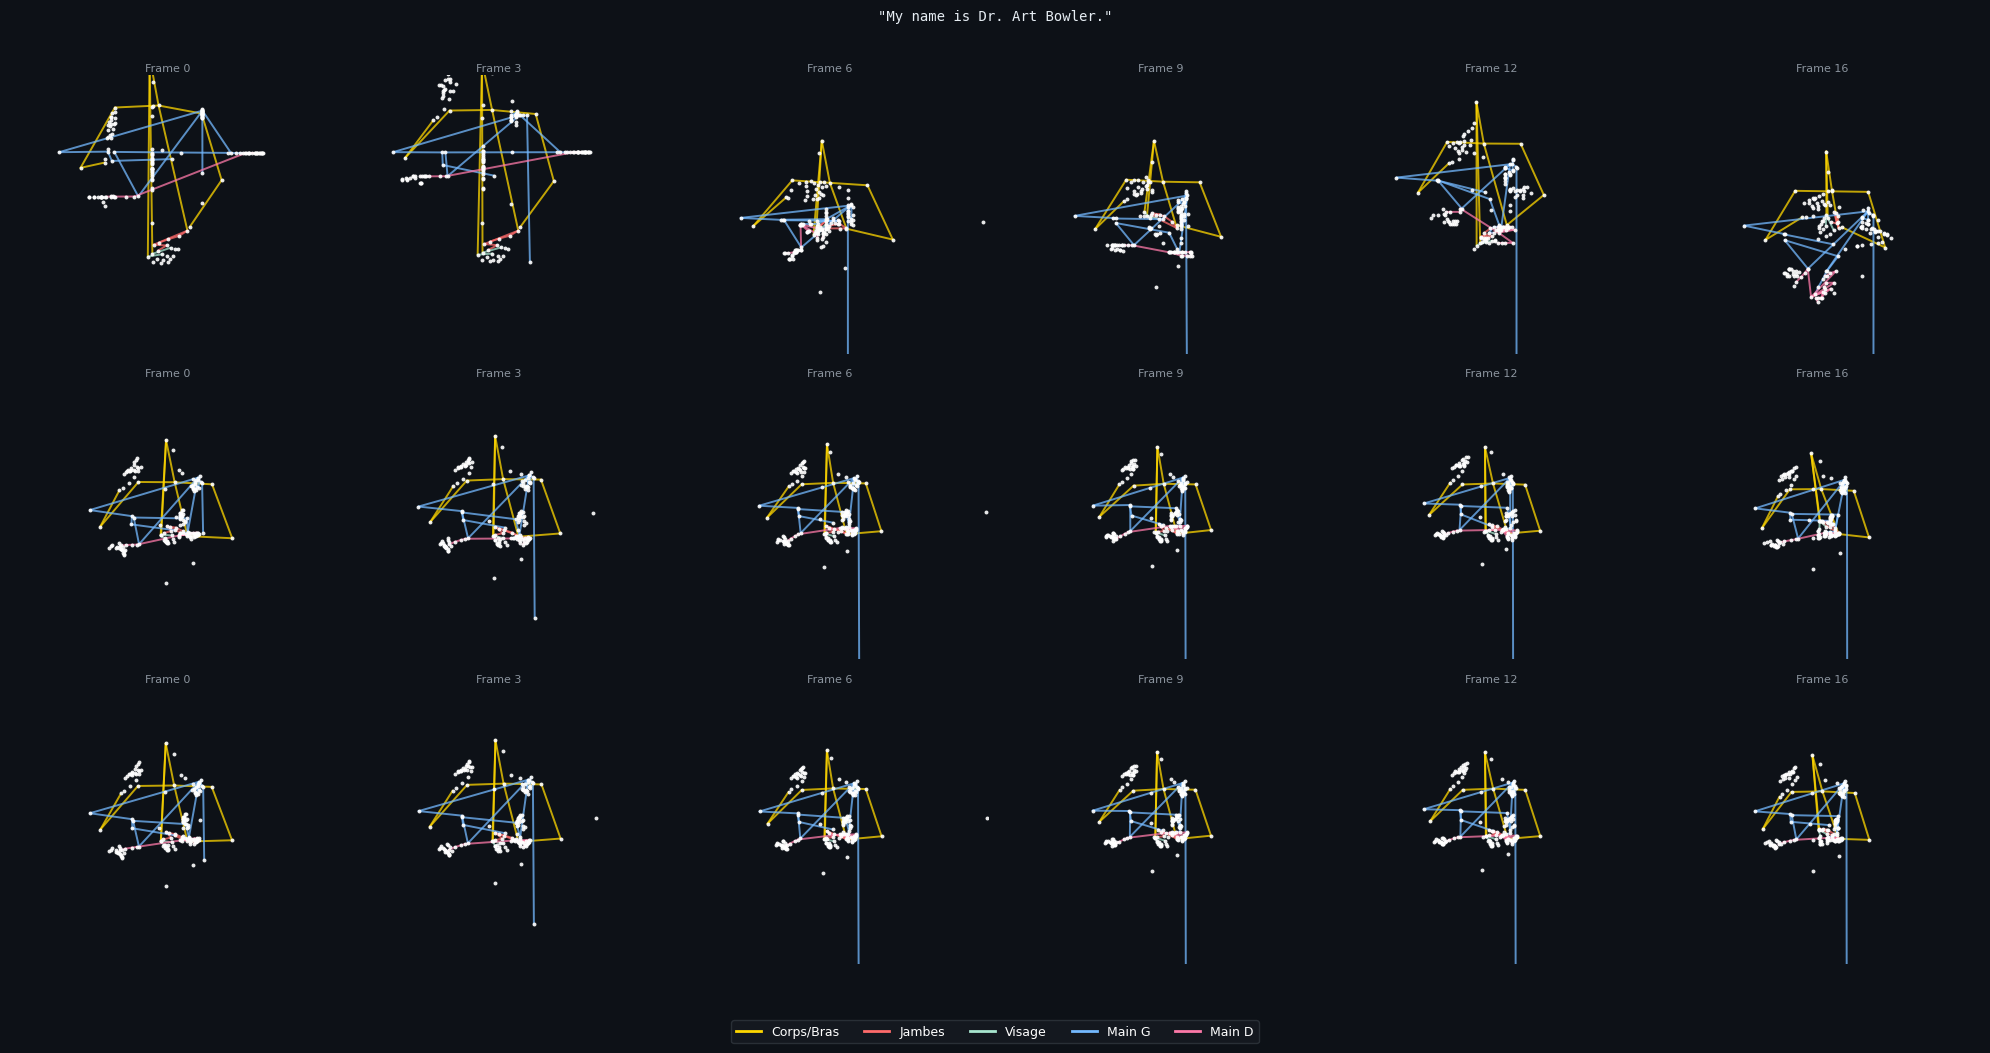

✅ viz_full_10.png sauvegardé


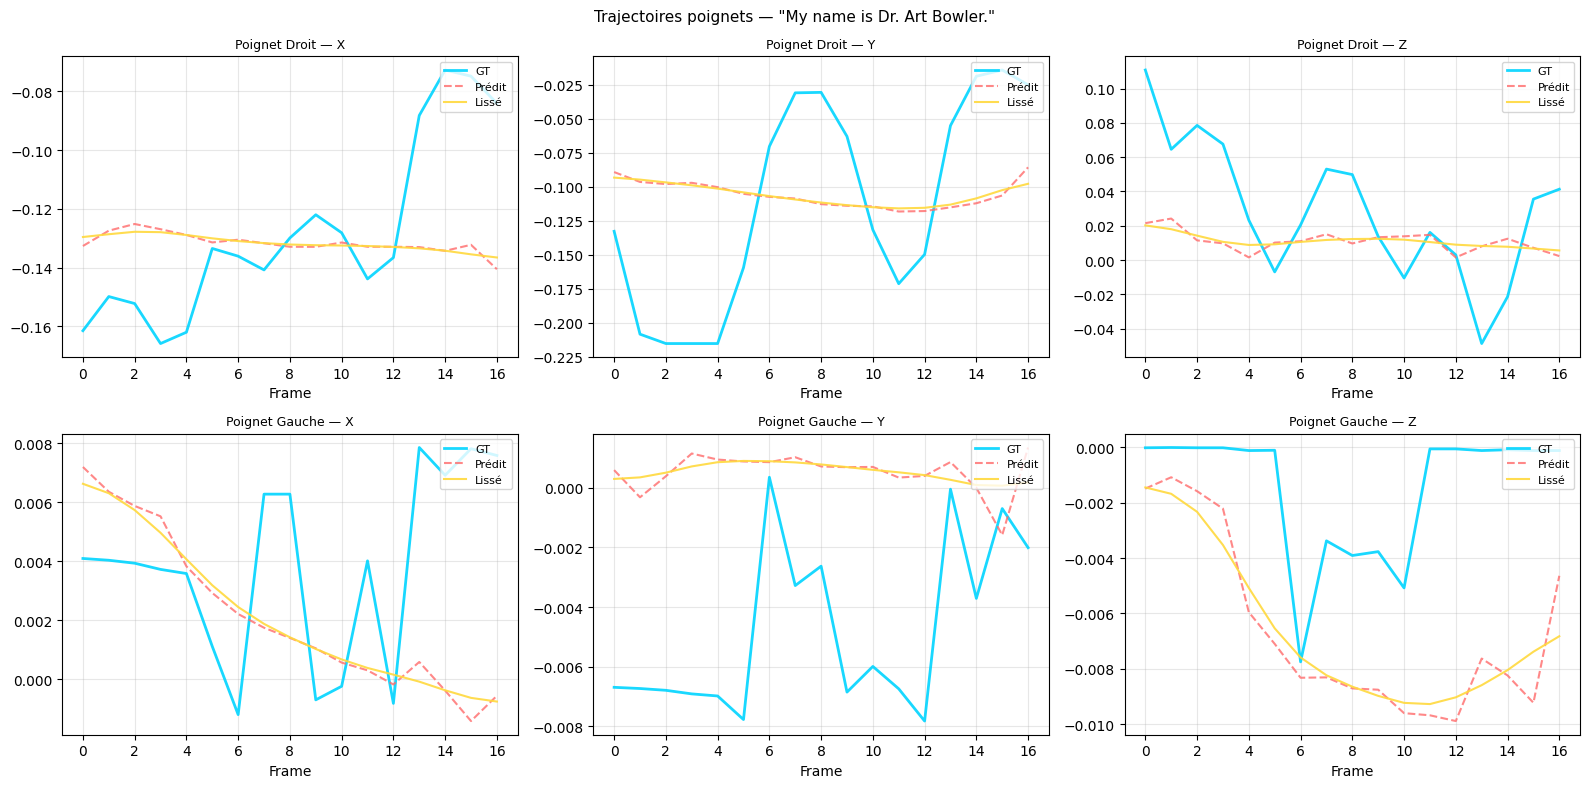

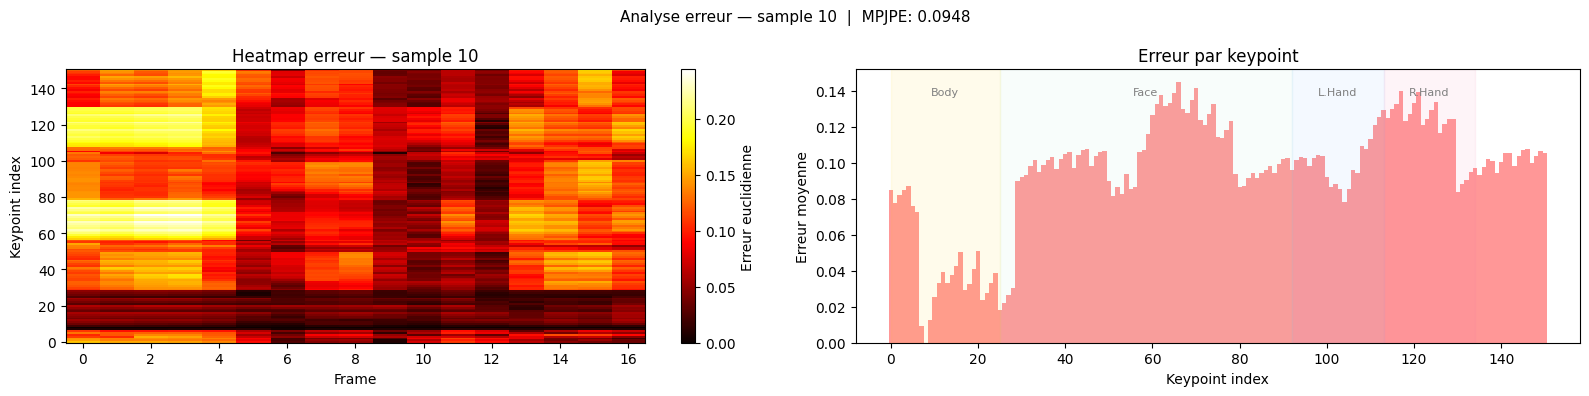

Sample 10 : 17 frames
  MPJPE          : 0.0948
  MPJPE lissé    : 0.0943
  Keypoint pire  : #66 (erreur moy = 0.1447)
  Région pire    : Face


In [24]:
from scipy.ndimage import gaussian_filter1d

# ── Connexions correctes OpenPose Body25 + mains ──────────────────
BODY_CONNECTIONS = [
    # Torse + bras
    (0, 1),   # nose -> neck
    (1, 2),   # neck -> right shoulder
    (2, 3),   # right shoulder -> right elbow
    (3, 4),   # right elbow -> right wrist
    (1, 5),   # neck -> left shoulder
    (5, 6),   # left shoulder -> left elbow
    (6, 7),   # left elbow -> left wrist
    # Hanches + jambes
    (1, 8),   # neck -> mid hip
    (8, 9),   # mid hip -> right hip
    (9, 10),  # right hip -> right knee
    (10, 11), # right knee -> right ankle
    (8, 12),  # mid hip -> left hip
    (12, 13), # left hip -> left knee
    (13, 14), # left knee -> left ankle
    # Visage
    (0, 15),  # nose -> right eye
    (0, 16),  # nose -> left eye
    (15, 17), # right eye -> right ear
    (16, 18), # left eye -> left ear
    # Main gauche (base = 92)
    (92, 93),  (93, 94),  (94, 95),  (95, 96),   # pouce
    (92, 97),  (97, 98),  (98, 99),  (99, 100),  # index
    (92, 101), (101, 102),(102, 103),(103, 104),  # majeur
    (92, 105), (105, 106),(106, 107),(107, 108),  # annulaire
    (92, 109), (109, 110),(110, 111),(111, 112),  # auriculaire
    # Main droite (base = 113)
    (113, 114),(114, 115),(115, 116),(116, 117),
    (113, 118),(118, 119),(119, 120),(120, 121),
    (113, 122),(122, 123),(123, 124),(124, 125),
    (113, 126),(126, 127),(127, 128),(128, 129),
    (113, 130),(130, 131),(131, 132),(132, 133),
]

# Couleurs par région pour mieux distinguer les parties du corps
REGION_COLORS = {
    'body' : '#FFD700',  # or     — torse/bras
    'legs' : '#FF6B6B',  # rouge  — jambes
    'face' : '#A8E6CF',  # vert   — visage
    'lhand': '#74B9FF',  # bleu   — main gauche
    'rhand': '#FD79A8',  # rose   — main droite
}

def get_connection_color(i, j, default_color):
    """Retourne la couleur selon la région anatomique de la connexion."""
    if i <= 7 or j <= 7:       return REGION_COLORS['body']
    if 8 <= i <= 14 or 8 <= j <= 14:  return REGION_COLORS['legs']
    if 15 <= i <= 24 or 15 <= j <= 24: return REGION_COLORS['face']
    if 92 <= i <= 112 or 92 <= j <= 112: return REGION_COLORS['lhand']
    if 113 <= i <= 133 or 113 <= j <= 133: return REGION_COLORS['rhand']
    return default_color


def smooth_poses(poses, sigma=1.5):
    """Lisse les poses sur la dimension temporelle."""
    smoothed = np.copy(poses)
    for kp in range(poses.shape[1]):
        for coord in range(poses.shape[2]):
            smoothed[:, kp, coord] = gaussian_filter1d(
                poses[:, kp, coord], sigma=sigma
            )
    return smoothed


def compute_global_lims(poses_list, indices):
    """
    Calcule les limites d'affichage communes à partir des GT poses,
    pour que GT / Prédit / Lissé soient sur la même échelle.
    """
    xs = np.concatenate([poses[indices, :, 0].flatten() for poses in poses_list])
    ys = np.concatenate([-poses[indices, :, 1].flatten() for poses in poses_list])
    # Filtrer les outliers extrêmes avant de calculer les limites
    xs = xs[np.isfinite(xs)]
    ys = ys[np.isfinite(ys)]
    x_mid   = np.median(xs)
    y_mid   = np.median(ys)
    spread  = max(np.percentile(np.abs(xs - x_mid), 95),
                  np.percentile(np.abs(ys - y_mid), 95)) * 1.4 + 0.05
    return x_mid, y_mid, spread


def plot_skeleton_connected(ax, frame, default_color='steelblue',
                             alpha=0.8, lims=None, use_region_colors=True):
    """
    Dessine un squelette connecté sur ax.
    lims = (x_mid, y_mid, spread) — limites communes pour comparaison équitable.
    """
    xs = frame[:, 0]
    ys = -frame[:, 1]   # inverser Y car coordonnées image (Y vers le bas)

    # Appliquer les limites communes ou calculer localement
    if lims is not None:
        x_mid, y_mid, spread = lims
    else:
        x_mid  = np.median(xs[np.isfinite(xs)])
        y_mid  = np.median(ys[np.isfinite(ys)])
        spread = max(np.nanstd(xs), np.nanstd(ys)) * 3 + 0.05

    ax.set_xlim(x_mid - spread, x_mid + spread)
    ax.set_ylim(y_mid - spread, y_mid + spread)

    # Dessiner les connexions avec couleurs par région
    for (i, j) in BODY_CONNECTIONS:
        if i < len(frame) and j < len(frame):
            if not (np.isfinite(xs[i]) and np.isfinite(xs[j])
                    and np.isfinite(ys[i]) and np.isfinite(ys[j])):
                continue
            color = get_connection_color(i, j, default_color) \
                    if use_region_colors else default_color
            ax.plot([xs[i], xs[j]], [ys[i], ys[j]],
                    c=color, alpha=0.75, linewidth=1.4, zorder=2, solid_capstyle='round')

    # Dessiner les keypoints par-dessus
    ax.scatter(xs, ys, s=8, c='white', alpha=0.9, zorder=3, linewidths=0)

    ax.axis('off')
    ax.set_aspect('equal', adjustable='datalim')


@torch.no_grad()
def visualize_full(model, dataset, stats, idx=0):
    model.eval()
    mean_np = stats['mean'].numpy()   # (151, 3)
    std_np  = stats['std'].numpy()    # (151, 3)

    sample         = dataset[idx]
    input_ids      = sample['input_ids'].unsqueeze(0).to(DEVICE)
    attention_mask = sample['attention_mask'].unsqueeze(0).to(DEVICE)
    gt_norm        = sample['poses'].numpy()          # (T, 151, 3) normalisé
    text           = sample['text']
    n_frames       = gt_norm.shape[0]

    # Générer les poses prédites
    pred_norm     = model.generate(input_ids, attention_mask,
                                   n_frames=n_frames)[0].cpu().numpy()

    # Dénormaliser vers l'espace original
    gt_poses      = gt_norm   * std_np + mean_np      # (T, 151, 3)
    pred_poses    = pred_norm * std_np + mean_np

    
    pred_smoothed = smooth_poses(pred_poses, sigma=1.5)

    n_show  = 6
    indices = np.linspace(0, min(len(gt_poses), len(pred_poses)) - 1,
                          n_show, dtype=int)

    # Limites communes calculées sur GT + Pred pour échelle cohérente
    global_lims = compute_global_lims([gt_poses, pred_poses], indices)

    # ── Plot 1 : Squelettes GT / Prédit / Lissé ─────────────────
    fig, axes = plt.subplots(3, n_show, figsize=(20, 10), facecolor='#0d1117')
    fig.suptitle(f'"{text[:110]}"', fontsize=10, color='#e6edf3',
                 y=1.01, fontfamily='monospace')

    row_labels = ['Ground Truth', 'Généré (brut)', 'Généré (lissé)']
    row_data   = [gt_poses, pred_poses, pred_smoothed]

    for col, fi in enumerate(indices):
        for row, (poses, label) in enumerate(zip(row_data, row_labels)):
            ax = axes[row, col]
            ax.set_facecolor('#0d1117')
            plot_skeleton_connected(ax, poses[fi], lims=global_lims,
                                    use_region_colors=True)
            ax.set_title(f'Frame {fi}', fontsize=8, color='#8b949e', pad=3)
            if col == 0:
                colors_row = ['#00d4ff', '#ff6b6b', '#ffd93d']
                ax.set_ylabel(label, fontsize=9, color=colors_row[row],
                              fontweight='bold', labelpad=4)

    # Légende des couleurs par région
    legend_elements = [
        plt.Line2D([0], [0], color=REGION_COLORS['body'],  lw=2, label='Corps/Bras'),
        plt.Line2D([0], [0], color=REGION_COLORS['legs'],  lw=2, label='Jambes'),
        plt.Line2D([0], [0], color=REGION_COLORS['face'],  lw=2, label='Visage'),
        plt.Line2D([0], [0], color=REGION_COLORS['lhand'], lw=2, label='Main G'),
        plt.Line2D([0], [0], color=REGION_COLORS['rhand'], lw=2, label='Main D'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=5,
               facecolor='#161b22', edgecolor='#30363d',
               labelcolor='white', fontsize=9, bbox_to_anchor=(0.5, -0.03))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(f'/kaggle/working/viz_full_{idx}.png',
                dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f"✅ viz_full_{idx}.png sauvegardé")

    # ── Plot 2 : Trajectoire temporelle des poignets ─────────────
    # Keypoints 4 (poignet droit) et 7 (poignet gauche) — les plus informatifs en ASL
    fig, axes2 = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle(f'Trajectoires poignets — "{text[:70]}"', fontsize=11)

    wrist_kps = [(4, 'Poignet Droit'), (7, 'Poignet Gauche')]
    coords    = ['X', 'Y', 'Z']

    for row, (kp_idx, kp_name) in enumerate(wrist_kps):
        for col, coord_name in enumerate(coords):
            ax = axes2[row, col]
            ax.plot(gt_poses[:, kp_idx, col],
                    color='#00d4ff', linewidth=2, label='GT', alpha=0.9)
            ax.plot(pred_poses[:, kp_idx, col],
                    color='#ff6b6b', linewidth=1.5, linestyle='--',
                    label='Prédit', alpha=0.8)
            ax.plot(pred_smoothed[:, kp_idx, col],
                    color='#ffd93d', linewidth=1.5,
                    label='Lissé', alpha=0.9)
            ax.set_title(f'{kp_name} — {coord_name}', fontsize=9)
            ax.legend(fontsize=8, loc='upper right')
            ax.grid(alpha=0.3)
            ax.set_xlabel('Frame')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/trajectory_{idx}.png', dpi=150)
    plt.show()

    # ── Plot 3 : Heatmap erreur par keypoint ────────────────────
    min_T  = min(len(gt_poses), len(pred_poses))
    errors = np.linalg.norm(pred_poses[:min_T] - gt_poses[:min_T], axis=-1)  # (T, 151)

    fig, axes3 = plt.subplots(1, 2, figsize=(16, 4))

    im = axes3[0].imshow(errors.T, aspect='auto', cmap='hot',
                          interpolation='nearest', origin='lower')
    plt.colorbar(im, ax=axes3[0], label='Erreur euclidienne')
    axes3[0].set_xlabel('Frame'); axes3[0].set_ylabel('Keypoint index')
    axes3[0].set_title(f'Heatmap erreur — sample {idx}')

    # Erreur moyenne par keypoint
    mean_err_per_kp = errors.mean(axis=0)   # (151,)
    axes3[1].bar(range(151), mean_err_per_kp, color='#ff6b6b', alpha=0.7, width=1.0)
    axes3[1].set_xlabel('Keypoint index')
    axes3[1].set_ylabel('Erreur moyenne')
    axes3[1].set_title('Erreur par keypoint')
    # Annoter les régions
    for label, (start, end) in [('Body', (0,25)), ('Face', (25,92)),
                                  ('L.Hand', (92,113)), ('R.Hand', (113,134))]:
        axes3[1].axvspan(start, end, alpha=0.08,
                          color=['#FFD700','#A8E6CF','#74B9FF','#FD79A8'][
                              ['Body','Face','L.Hand','R.Hand'].index(label)])
        axes3[1].text((start+end)/2, mean_err_per_kp.max()*0.95,
                       label, ha='center', fontsize=8, color='gray')

    plt.suptitle(f'Analyse erreur — sample {idx}  |  MPJPE: {errors.mean():.4f}',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/heatmap_{idx}.png', dpi=150)
    plt.show()

    # ── Stats ─────────────────────────────────────────────────────
    worst_kp  = mean_err_per_kp.argmax()
    print(f"Sample {idx} : {n_frames} frames")
    print(f"  MPJPE          : {errors.mean():.4f}")
    print(f"  MPJPE lissé    : {np.linalg.norm(pred_smoothed[:min_T] - gt_poses[:min_T], axis=-1).mean():.4f}")
    print(f"  Keypoint pire  : #{worst_kp} (erreur moy = {mean_err_per_kp[worst_kp]:.4f})")
    region = ('Body' if worst_kp < 25 else 'Face' if worst_kp < 92
              else 'Main G' if worst_kp < 113 else 'Main D')
    print(f"  Région pire    : {region}")


# ── Lancer la visualisation ────────────────────────────────────────
for idx in [0, 5, 10]:
    print(f"\n{'─'*50}")
    print(f"Visualisation sample {idx}")
    print(f"{'─'*50}")
    visualize_full(model_with, train_ds, stats, idx=idx)

# Sauvegarde résultats combinés

In [25]:
import os
import json as _json
import csv
import numpy as np

# =========================
# ✅ PATH CONFIG (FIXED)
# =========================
INPUT_DIR  = "/kaggle/input/datasets/sarraverse/outputs-approach-b"  # read-only (for loading if exists)
OUTPUT_DIR = "/kaggle/working/outputs-approach-b"                    # write here

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# ✅ SAFE JSON LOADER
# =========================
def _load_result(path, fallback):
    try:
        if os.path.exists(path):
            with open(path) as f:
                return _json.load(f)
    except Exception as e:
        print(f"⚠️ Warning loading {path}: {e}")
    return fallback

# Try loading from INPUT_DIR first, fallback to OUTPUT_DIR
res_with = _load_result(f"{INPUT_DIR}/results_with.json",
           _load_result(f"{OUTPUT_DIR}/results_with.json", {}))

res_without = _load_result(f"{INPUT_DIR}/results_without.json",
              _load_result(f"{OUTPUT_DIR}/results_without.json", {}))

# =========================
# ✅ BUILD RESULTS TABLE
# =========================
rows = [
    {
        'approach'       : 'B_with_contribution',
        'description'    : f'DDPM + STC + CrossAttn (T={T_DIFF}, base_ch=128)',
        'best_train_loss': res_with.get('best_train_loss', round(min(history_with['train']), 4)),
        'best_dev_loss'  : res_with.get('best_dev_loss',   round(min(history_with['dev']),   4)),
        'mpjpe_dev'      : round(mpjpe_with, 4),
        'dtw_dev'        : round(dtw_with,   4),
        'best_epoch'     : res_with.get('best_epoch', int(np.argmin(history_with['dev']) + 1)),
    },
    {
        'approach'       : 'B_without_contribution',
        'description'    : f'DDPM baseline ablation (T={T_DIFF}, base_ch=128)',
        'best_train_loss': res_without.get('best_train_loss', round(min(history_without['train']), 4)),
        'best_dev_loss'  : res_without.get('best_dev_loss',   round(min(history_without['dev']),   4)),
        'mpjpe_dev'      : round(mpjpe_without, 4),
        'dtw_dev'        : round(dtw_without,   4),
        'best_epoch'     : res_without.get('best_epoch', int(np.argmin(history_without['dev']) + 1)),
    }
]

# =========================
# ✅ SAVE CSV (FIXED)
# =========================
csv_path = f"{OUTPUT_DIR}/results_approach_b.csv"

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

# =========================
# ✅ PRINT COMPARISON TABLE
# =========================
print(f"\n{'='*55}")
print(f"{'Métrique':<20} {'AVEC STC':>12} {'SANS STC':>12} {'Gain':>10}")
print(f"{'-'*55}")
print(f"{'MPJPE ↓':<20} {mpjpe_with:>12.4f} {mpjpe_without:>12.4f} {mpjpe_without - mpjpe_with:>+10.4f}")
print(f"{'DTW ↓':<20} {dtw_with:>12.4f} {dtw_without:>12.4f} {dtw_without - dtw_with:>+10.4f}")
print(f"{'='*55}")
print("↓ = plus bas est mieux | Gain positif = STC aide")

# =========================
# ✅ FILE CHECK
# =========================
print(f"\n✅ results_approach_b.csv saved to: {csv_path}")
print(f"\n📂 Files in {OUTPUT_DIR}:")

for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f"{OUTPUT_DIR}/{fname}") / 1024
    print(f"  {fname:50s} {size:8.1f} KB")


Métrique                 AVEC STC     SANS STC       Gain
-------------------------------------------------------
MPJPE ↓                    0.0957       0.0973    +0.0016
DTW ↓                      0.6396       0.6392    -0.0003
↓ = plus bas est mieux | Gain positif = STC aide

✅ results_approach_b.csv saved to: /kaggle/working/outputs-approach-b/results_approach_b.csv

📂 Files in /kaggle/working/outputs-approach-b:
  results_approach_b.csv                                  0.3 KB
